# GHIM Energy Module — Electricity Supply Sector: Framework & Validation

This notebook has two parts:

**Part I — Model Framework** (Sections 1–2): Complete description of how
electricity demand and supply are determined within the GHIM Energy Module.
Covers the full causal chain from GDP to generation mix, with all formulas,
parameters, data sources, and code references.

**Part II — Validation** (Sections 3–13): Quantitative checks that each
model component produces reasonable results under SSP2.

**Companion notebooks:** `klem_validation.ipynb` (macro), `trade_validation.ipynb` (trade)

> **Note:** The GHIM Energy Module is one component of the broader GHIM
> (Global Hybrid Integrated Model) framework. This notebook documents only the
> electricity supply sector within the energy module.

In [1]:
import sys
import math
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({"figure.figsize": (14, 6), "font.size": 11})

from ghim.data.ssp import load_ssp_data
from ghim.data.energy_cal import (
    DEFAULT_FINAL_DEMAND, DEFAULT_ELEC_TOTAL_EJ,
    DEFAULT_ELEC_SHARES, DEFAULT_PRIMARY_ENERGY,
)
from ghim.econ.klem import KLEMDriver
from ghim.config import (
    BASE_YEAR, MODEL_YEARS, TIMESTEP, HOURS_PER_YEAR,
    CAPITAL_OUTPUT_RATIO, LABOR_FORCE_PARTICIPATION, CAPITAL_SHARE,
    SAVINGS_RATE, DISCOUNT_RATE, SIGMA_EM,
    ELEC_LOGIT_EXP, PREF_LOGIT_SCALE, PREF_DECAY_RATE,
    TURNOVER_TIMES, LEARNING_RATES, COST_FLOOR_FRACTION,
    PRICE_TOL, MAX_PRICE_ITER, PRICE_DAMP,
    CARBON_COEFS, TC_TO_TCO2,
    capital_recovery_factor,
)
from ghim.regions import R10_REGIONS
from ghim.energy.electricity import ElectricitySector
from ghim.energy.technology import Technology, default_electricity_techs
from ghim.energy.logit import preference_logit, preference_calibrate
from ghim.energy.stock import apply_stock_turnover
from ghim.energy.demand import ENERGY_CARRIERS, INCOME_ELASTICITY, DEFAULT_FUEL_SHARES
from ghim.solver.recursive import run_model, build_region_model
from ghim.output.reporting import results_to_dataframe

print(f"Python {sys.version}")
print(f"Regions: {len(R10_REGIONS)}, Periods: {len(MODEL_YEARS)} ({MODEL_YEARS[0]}–{MODEL_YEARS[-1]})")
print(f"Base year: {BASE_YEAR}, Timestep: {TIMESTEP} yr")
print(f"Technologies: {[t.name for t in default_electricity_techs()]}")

Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
Regions: 10, Periods: 31 (2000–2150)
Base year: 2020, Timestep: 5 yr
Technologies: ['coal', 'gas_cc', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'oil']


---
# Part I — Model Framework

## 1. Overall Architecture

The GHIM Energy Module is a **recursive-dynamic** integrated energy-economy
model. Each 5-year period is solved independently (forward in time), with
capital and technology states carried forward. The model runs 10 AR6 R10
regions simultaneously.

### System Diagram

The diagram below shows both the **top-down causal flow** (solid arrows) and
the **feedback loops** (dashed arrows) that create endogenous price–quantity
equilibria.

```
┌─────────────────────────────────────────────────────────────────────┐
│                         MACRO LAYER                                │
│  SSP GDP/Pop ──→ KLEM: Y = A·K^α·L^(1-α) ──→ Total energy demand │
│                                           ▲                        │
│              energy cost feedback ─ ─ ─ ─ ┘                        │
└───────────────────────────┬─────────────────────────────────────────┘
                            │
                            ▼
┌─────────────────────────────────────────────────────────────────────┐
│                     FINAL DEMAND LAYER                             │
│  Industry  (ε=0.6, income elast.)  ──┐                             │
│  Buildings (ε=0.5, income elast.)  ──┼→ Carrier choice (pref logit)│
│  Transport (ε=0.7, income elast.)  ──┘   + stock turnover at each │
│                                           nesting level            │
│                             ↓                                      │
│                      Demand by carrier:                            │
│              coal, gas, liquids, electricity, biomass, H₂          │
│                          ▲                                         │
│    carrier prices ─ ─ ─ ─┘  (feedback from transformation layer)   │
└───────────────────────────┬─────────────────────────────────────────┘
                            │
                            ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    TRANSFORMATION LAYER                            │
│                                                                    │
│  Electricity sector     Refining sector      Hydrogen sector       │
│  ┌────────────────┐     ┌──────────────┐     ┌──────────────────┐  │
│  │ 8 technologies │     │ Oil refining │     │ SMR, Electrolysis│  │
│  │ Preference logit│     │ (single tech)│     │ Preference logit │  │
│  │ Stock turnover │     └──────────────┘     │ Stock turnover   │  │
│  │ Learning curves│                          │ Learning curves  │  │
│  └───────┬────────┘                          └──────────────────┘  │
│          │  ▲                                                      │
│          │  └ ─ fuel prices from trade (feedback)                  │
│          ▼                                                         │
│    Weighted-avg LCOE ═══► electricity price ──→ demand feedback    │
└───────────────────────────┬─────────────────────────────────────────┘
                            │
                            ▼
┌─────────────────────────────────────────────────────────────────────┐
│                     PRIMARY SUPPLY LAYER                           │
│  Inter-regional trade: global market clearing for coal, oil, gas   │
│  Grade-based supply curves (GCAM) ──→ world prices via bisection   │
│          │                                                         │
│          └ ─ ─ ─ fuel prices feed back to LCOE (upward) ─ ─ ─ ─ ▲ │
└─────────────────────────────────────────────────────────────────────┘
```

**Key feedback loops** (not visible in a purely top-down reading):

1. **Price iteration** (Section 2J): Electricity price → carrier choice →
   electricity demand → generation mix → new LCOE → updated price.
   Converges via damped fixed-point iteration within each period.
2. **Trade feedback**: World fuel prices (coal, gas, oil from bisection) →
   LCOE of thermal technologies → generation mix → fuel demand → next
   iteration of market clearing.
3. **GDP feedback**: Energy cost → net GDP adjustment → investment →
   future capital stock → future GDP → future energy demand.

### Stock turnover structure

Stock turnover is **not** applied only at the sector level — it is applied
recursively at **every level** of the nested demand tree via
`compute_carrier_demands()`:

- Transport root (50 yr) → Passenger / Freight subsectors (15 yr each) → fuel leaves
- Industry root (50 yr) → Heavy / Light / Data centers (30 / 30 / 7 yr) → fuel leaves
- Buildings root (60 yr) → Residential / Commercial (50 yr each) → fuel leaves
- Electricity sector: turnover at the technology level (40 yr)

At each nesting level, the turnover formula blends current shares toward
logit-determined target shares, so the overall transition pace is governed
by the **slowest** turnover time in the chain.

### What determines the electricity price?

The electricity price is the **weighted-average LCOE** across all 8 generation
technologies, where weights are the generation shares. This price feeds back
into the demand layer as the "cost of electricity" in the carrier-choice logit.
A price iteration loop ensures demand and supply are mutually consistent.

### Regional scope

| # | AR6 R10 Region |
|---|----------------|
| 1 | North America |
| 2 | Europe |
| 3 | Asia-Pacific Developed |
| 4 | Eurasia |
| 5 | Eastern Asia |
| 6 | Southern Asia |
| 7 | South-East Asia and developing Pacific |
| 8 | Middle East |
| 9 | Latin America and Caribbean |
| 10 | Africa |

**Source:** IPCC AR6 WGIII Annex II regional classification.
Country→R10 mapping: `ghim/data/external/region_classification.tsv` (direct ISO→R10).

## 2. Electricity Demand and Supply: The Full Chain

This section walks through every step from GDP to generation mix.
Each subsection states the formula, explains the mechanism, identifies
all parameters and their sources, and gives the code location.

### 2A. Total Energy Demand (KLEM Production Function)

The macro layer uses a **DICE-style Cobb-Douglas** production function:

$$Y = A(t) \cdot K(t)^{\alpha} \cdot L(t)^{1-\alpha}$$

where $A(t)$ = TFP (calibrated to reproduce SSP GDP), $K$ = capital stock,
$L$ = labor force, $\alpha = 0.3$ = capital share.

**Total energy demand** responds to GDP and the composite energy price index:

$$E(t) = E_{\text{base}} \cdot \frac{Y(t)}{Y_{\text{base}}} \cdot \left(\frac{P(t)}{P_{\text{base}}}\right)^{-\sigma_{EM}}$$

| Parameter | Value | Source |
|-----------|:-----:|--------|
| $\alpha$ (capital share) | 0.30 | PWT 10.01, cross-country median |
| $\sigma_{EM}$ (energy-macro elasticity) | 0.50 | Koetse et al. (2008) meta-analysis of energy-economy substitution |
| $E_{\text{base}}$ | Region-specific (EJ) | Sum of `DEFAULT_FINAL_DEMAND` values from IEA World Energy Balances 2021 |
| $Y_{\text{base}}$, $L_{\text{base}}$ | From SSP database | IIASA SSP Public Database v2.0 (Riahi et al., 2017) |

> **Planned improvement:** The energy-macro elasticity $\sigma_{EM}$ is
> currently a global constant (`config.py:SIGMA_EM = 0.50`). The vision is
> that all key parameters should be: (1) configurable rather than hardcoded,
> (2) optionally regional (different values per R10 region), and
> (3) backed by empirical calibration. Parameter regionalization is a
> separate task tracked outside this notebook.

**Code:** `klem.py:compute_energy_demand()` (lines 152–175)

### 2B. Sector-Level Demand Scaling

Total energy is not allocated directly. Instead, three **final demand sectors**
each have their own demand level that scales with GDP via income elasticities:

$$E_{\text{sector}}(t) = E_{\text{base,sector}} \cdot \left(\frac{GDP(t)}{GDP_{\text{base}}}\right)^{\varepsilon}$$

| Sector | Base demand (EJ) | Income elasticity $\varepsilon$ | Source |
|--------|:----:|:------:|--------|
| Industry | Region-specific | 0.6 | IEA WEO 2023, Table 4.2 — historical energy/GDP elasticities for industrial sectors |
| Buildings | Region-specific | 0.5 | Reflects saturation in residential/commercial energy demand at high income levels |
| Transport | Region-specific | 0.7 | IEA Mobility Model 2023; income-driven motorization in developing regions |

Base demands by region (EJ, approximate 2020 values from IEA World Energy Balances 2021):

| Region | Industry | Buildings | Transport |
|--------|:----:|:--------:|:--------:|
| North America | 18.0 | 20.0 | 28.0 |
| Europe | 13.0 | 18.0 | 14.0 |
| Eastern Asia | 45.0 | 15.0 | 15.0 |
| Southern Asia | 12.0 | 8.0 | 5.0 |
| Africa | 4.0 | 8.0 | 4.0 |
| *(others)* | *see `energy_cal.py`* | | |

**Code:** `demand.py:FinalDemand.compute_demand()` (lines 314–332),
`energy_cal.py:DEFAULT_FINAL_DEMAND` (lines 114–125)

### 2C. Carrier Choice: Preference Factor Logit

Within each sector, total demand is allocated across **6 energy carriers**
(coal, refined liquids, gas, electricity, biomass, hydrogen) via a
**MERGE-style preference factor logit** (Manne & Richels, 2004):

$$\text{Share}_i = \frac{\exp\bigl(-k\,(C_i + P_i)\bigr)}
                        {\sum_j \exp\bigl(-k\,(C_j + P_j)\bigr)}$$

**Key features of this formulation:**

- $C_i$ = delivered cost of carrier $i$ ($/GJ) — for electricity, this is the
  weighted-average LCOE; for fossil fuels, it's the world trade price or
  exogenous price.
- $P_i$ = **preference factor** — a calibrated adder ($/GJ equivalent) that
  captures everything beyond pure cost: infrastructure lock-in, consumer
  habits, policy support, resource availability.
- $k = 0.3\;(\$/\text{GJ})^{-1}$ = sensitivity parameter. A \$1/GJ cost
  difference shifts relative shares by $e^{0.3} \approx 1.35\times$.

#### Technology Choice Across IAMs

To position the GHIM Energy Module's preference logit within the broader
literature, we compare technology choice mechanisms across major IAMs:

| Model | Tech Choice Mechanism | Non-cost Factors |
|-------|----------------------|------------------|
| **GCAM** | Relative-cost logit: $s_i = \alpha_i p_i^\gamma / \Sigma$ | Share weights $\alpha$ (static, calibrated) |
| **MERGE** | Preference logit: $\exp(-k(C+P))$ | Additive preference $P$ (static) |
| **WITCH** | R&D + two-factor learning curves | Endogenous via R&D investment decisions |
| **REMIND** | Cost optimization + learning + vintage structure | Adjustment costs (deployment barriers) |
| **MESSAGE/TIAM** | Linear programming cost minimization | Implicit in cost constraints and bounds |

**GHIM's current approach** uses the MERGE-style additive preference $P$.
This is **not too rigid per se** — it cleanly separates cost from non-cost
factors and allows exact base-year calibration. However, several
generalization paths are available (without removing $P$):

1. **Time-varying $P$:** $P(t) = P_{\text{base}} \times (1 - d)^{t-t_0}$
   where $d$ = decay rate. Already defined as `PREF_DECAY_RATE = 0.02` in
   `config.py` but **not yet wired** in the solver. When activated, non-cost
   barriers would erode over time (~10% per period, halving in ~35 years).
2. **Multiplicative form:** $C_{\text{eff}} = C \times (1 + P_{\text{mult}})$
   — scales the penalty with cost level (expensive tech gets larger absolute
   penalty).
3. **Technology-specific decay:** Different decay rates by technology (e.g.,
   fast decay for solar barriers, slow for nuclear acceptance issues).
4. **Policy-responsive $k$:** Logit sensitivity that increases under carbon
   pricing, reflecting heightened cost-consciousness.
5. **Nested logit** with differentiated scale parameters at different tree
   levels (sector → subsector → technology), following IIA relaxation as in
   GCAM's nested logit structure.

These generalizations are planned for future development. The current
constant-$P$ formulation provides a clean, interpretable baseline.

**Calibration (inverse logit):**
Given observed base-year shares $S_i$ and costs $C_i$, pick the reference
technology $r$ (largest share) and set $P_r = 0$. Then:

$$P_i = (C_r - C_i) - \frac{\ln(S_i / S_r)}{k}$$

This ensures the model exactly reproduces base-year shares.

**Interpretation of preference factors:**
- $P_i < 0$ → **bonus**: technology is chosen more than its cost alone
  would justify (e.g., gas in Middle East — cheap infrastructure)
- $P_i > 0$ → **penalty**: technology faces non-cost barriers
  (e.g., nuclear in many regions — public acceptance, regulation)
- $P_i = 0$ → reference technology (most popular in base year)

**Comparison to GCAM's relative-cost logit:**

| Feature | GHIM (preference logit) | GCAM (relative-cost logit) |
|---------|:---:|:---:|
| Formula | $\exp(-k(C+P))$ | $\alpha \cdot C^{\beta}$ |
| Parameters | scale $k$, additive prefs $P$ | exponent $\beta$, weights $\alpha$ |
| Cost sensitivity | Constant | Varies with cost level |
| Non-cost factors | Explicit additive term | Implicit in weights |
| Origin | MERGE (Manne & Richels, 2004) | GCAM (Wise et al., 2014) |

| Parameter | Value | Source |
|-----------|:-----:|--------|
| $k$ (logit scale) | 0.30 ($/GJ)$^{-1}$ | Calibrated to reproduce observed technology diversity; comparable to MERGE default |
| Base-year carrier shares | Region × sector specific | IEA World Energy Balances 2021, aggregated to R10 |

**Code:** `logit.py:preference_logit()` (lines 175–205),
`logit.py:preference_calibrate()` (lines 208–247)

### 2D. Stock Turnover

Neither carrier shares (in demand) nor technology shares (in electricity
supply) switch instantly. Existing capital stock constrains the pace of
transition. The stock turnover formula is a **first-order exponential filter**:

$$S_{i}^{t+1} = S_{i}^{t} + \frac{\Delta t}{\tau}\,\bigl(S_{i}^{\text{target}} - S_{i}^{t}\bigr)$$

where $\tau$ is the turnover time (characteristic replacement period) and
$\Delta t = 5$ yr is the model timestep.

**Interpretation:** Each period, a fraction $\Delta t / \tau$ of the fleet is
replaced. New investment follows the logit-determined target shares; the rest
retains its current composition. The gap between current and target shares
halves every $\tau \cdot \ln 2 / (\Delta t / \tau)$ ≈ 26 years for electricity.

| Sector | $\tau$ (yr) | Blend rate | Half-life | Source |
|--------|:---:|:---:|:---:|--------|
| Electricity | 40 | 12.5%/period | 26 yr | Average power plant economic lifetime (NREL ATB 2023) |
| Hydrogen | 25 | 20%/period | 16 yr | Electrolyzer/SMR plant lifetime |
| Transport | 15 | 33%/period | 8 yr | Vehicle fleet turnover (IEA Global EV Outlook 2023) |
| Industry | 30 | 17%/period | 19 yr | Boilers, furnaces, process equipment |
| Buildings | 50 | 10%/period | 33 yr | Heating systems, building shell |
| Refining | 40 | 12.5%/period | 26 yr | Refinery infrastructure |
| Data centers | 7 | 71%/period | 3 yr | Server hardware lifecycle |

**Code:** `stock.py:apply_stock_turnover()` (lines 17–52),
`config.py:TURNOVER_TIMES` (lines 67–75)

### 2E. From Carrier Demand to Electricity Demand

After the logit and stock turnover steps in each sector, the electricity
demand for that sector is determined. Total electricity demand is simply
the sum:

$$E_{\text{elec}} = \sum_{\text{sectors}} D_{\text{electricity,sector}}$$

Base-year electricity shares in final demand (from `DEFAULT_FUEL_SHARES`):

| Sector | Electricity share | Source |
|--------|:---------:|--------|
| Industry | 25% | IEA Energy Balance 2020 (global average, industrial electricity consumption ÷ total industrial energy) |
| Buildings | 40% | IEA Energy Balance 2020 (residential + commercial) |
| Transport | 3% | IEA Global EV Outlook 2023 (battery EVs + rail) |

These shares evolve endogenously as electricity becomes cheaper (via learning)
relative to other carriers.

**Code:** `demand.py:DEFAULT_FUEL_SHARES` (lines 53–66)

### 2F. Electricity Supply: 8 Technologies

The electricity sector has 8 generation technologies. All compete via
the same preference logit mechanism described in Section 2C, applied
specifically to electricity with its own parameters.

**Technology set:**

| Technology | Type | Fuel input | Learning? |
|------------|------|------------|-----------|
| Coal | Thermal (supercritical) | Coal | No (mature) |
| Gas CCGT | Thermal (combined cycle) | Natural gas | No (mature) |
| Nuclear | Thermal (Gen III+) | Uranium | Yes (3%) |
| Hydro | Renewable (conventional) | Water | No (site-limited) |
| Wind | Renewable (onshore) | Wind | Yes (12%) |
| Solar | Renewable (utility PV) | Solar irradiance | Yes (20%) |
| Biomass | Thermal (dedicated plant) | Biomass | Yes (5%) |
| Oil | Thermal (combustion turbine) | Refined liquids | No (declining) |

> **Naming convention — `gas_cc` vs `gas`:**
> The electricity technology is named `gas_cc` (combined-cycle gas turbine),
> **not** `gas`. This is intentional and protective:
> - `gas_cc` = electricity **technology** name (the specific power plant type)
> - `gas` = **fuel carrier** name (appears in `ENERGY_CARRIERS`, `CARBON_COEFS`,
>   trade supply curves, and demand-side carrier choice)
> - The technology's `fuel_input` field is `"gas"`, so the model correctly maps
>   `gas_cc` technology → `gas` fuel for cost and emissions calculations.
> - **No double-counting risk:** electricity emissions use the `Technology`
>   object's own `carbon_coef` (0.0153 tC/GJ), not `CARBON_COEFS["gas"]`.
>   These are separate accounting paths.
> - Renaming to just `"gas"` would create ambiguity with the fuel carrier —
>   the current separation is intentional.

**Technology parameters and their sources:**

| Parameter | Description | Source |
|-----------|-------------|--------|
| Capital cost ($/kW) | Overnight construction cost | NREL Annual Technology Baseline (ATB) 2023, "Moderate" technology scenario |
| Fixed O&M ($/kW/yr) | Annual fixed operating cost | NREL ATB 2023 (matched to Moderate case, rounded to nearest $5) |
| Variable O&M ($/GJ) | Per-unit operating cost | NREL ATB 2023 + IEA WEO 2023 (converted from $/MWh ÷ 3.6) |
| Capacity factor | Annual average utilization | IEA World Energy Outlook 2023 (Table A.2) + IRENA Renewable Capacity Statistics 2023 |
| Efficiency ($\eta$) | Output/input energy ratio | IEA WEO 2023 + GCAM v7.0 defaults (HHV basis for thermal) |
| Lifetime (years) | Economic operating life | NREL ATB 2023 + GCAM v7.0 |
| Carbon coefficient (tC/GJ) | Combustion emissions factor | IPCC 2006 Guidelines, Vol 2, Table 1.4 |
| Learning rate | Cost reduction per capacity doubling | IRENA Renewable Power Generation Costs 2022, Figure 3.2 |
| Base cumulative capacity (GW) | 2020 global installed base | IRENA Renewable Capacity Statistics 2021, IAEA PRIS database |

**Specific parameter values:**

| Tech | CapEx ($/kW) | O&M fix ($/kW/yr) | O&M var ($/GJ) | CF | $\eta$ | Life (yr) | C coef (tC/GJ) |
|------|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| Coal | 1,500 | 40 | 0.5 | 0.75 | 0.39 | 40 | 0.0257 |
| Gas CCGT | 900 | 12 | 0.3 | 0.60 | 0.55 | 30 | 0.0153 |
| Nuclear | 5,500 | 100 | 0.5 | 0.90 | 0.33 | 60 | 0.0 |
| Hydro | 2,500 | 30 | 0.1 | 0.45 | 1.00 | 80 | 0.0 |
| Wind | 1,200 | 25 | 0.0 | 0.35 | 1.00 | 25 | 0.0 |
| Solar | 900 | 12 | 0.0 | 0.22 | 1.00 | 30 | 0.0 |
| Biomass | 2,500 | 50 | 0.5 | 0.70 | 0.35 | 30 | 0.0 |
| Oil | 800 | 15 | 0.8 | 0.30 | 0.37 | 30 | 0.0200 |

**Important caveat:** These are **global-average representative values**.
Real costs vary significantly by region, site, and project. The model does
not (yet) differentiate technology costs by region — all 10 regions share
the same technology cost assumptions. Regional differences in electricity
mix arise from different **base-year shares** (which produce different
calibrated preference factors) and different **fuel prices** (which shift
the LCOE of thermal technologies).

**Code:** `technology.py:default_electricity_techs()` (lines 105–148)

### 2G. LCOE Computation

The **Levelized Cost of Energy** converts heterogeneous cost components
(upfront capital, annual O&M, fuel) into a single $/GJ metric that enables
technology comparison:

$$\text{LCOE} = \underbrace{\frac{C_{\text{cap}} \cdot \text{CRF}}{CF \cdot 8760 \cdot 3.6\times10^{-3}}}_{\text{capital}}
  + \underbrace{\frac{C_{\text{OM,fix}}}{CF \cdot 8760 \cdot 3.6\times10^{-3}}}_{\text{fixed O\&M}}
  + \underbrace{\frac{P_{\text{fuel}}}{\eta}}_{\text{fuel}}
  + \underbrace{C_{\text{OM,var}}}_{\text{variable O\&M}}$$

where:
- $C_{\text{cap}}$ = capital cost ($/kW)
- $\text{CRF} = \frac{r(1+r)^n}{(1+r)^n - 1}$ = capital recovery factor
  (annualizes investment over $n$-year lifetime at discount rate $r$)
- $CF$ = capacity factor (0–1)
- $8760$ = hours per year
- $3.6 \times 10^{-3}$ = GJ per kWh
- $P_{\text{fuel}}$ = fuel price ($/GJ)
- $\eta$ = thermal efficiency

**Units derivation:** 1 kW at capacity factor $CF$ produces:
$CF \times 8760\;\text{h/yr} \times 3.6\times10^{-3}\;\text{GJ/kWh} = CF \times 31.536\;\text{GJ/yr per kW}$

**Fuel prices and their sources:**

| Fuel | Price ($/GJ) | Source |
|------|:---:|--------|
| Coal | 1.75 | BP Statistical Review 2021: steam coal average $59.57/tonne ÷ 34.12 GJ/t |
| Natural gas | 3.85 | Henry Hub 2020: $4.06/mmBtu ÷ 1.055 GJ/mmBtu |
| Oil (refined liquids) | 6.76 | Brent 2020: $41.84/bbl ÷ 6.193 GJ/bbl |
| Nuclear (uranium) | 0.70 | NEA/OECD 2020: uranium + enrichment + fabrication |
| Biomass | 2.50 | IEA Bioenergy 2020: wood pellet global average |
| Wind/Solar/Hydro | 0.00 | Zero fuel cost by definition |

The discount rate $r = 0.05$ (5%) is a social discount rate consistent with
DICE and RICE integrated assessment models.

**Code:** `technology.py:Technology.levelized_cost()` (lines 51–70),
`config.py:capital_recovery_factor()` (lines 119–123),
`config.py:OBSERVED_FUEL_PRICES_2020` (lines 154–158)

### 2H. Electricity Technology Competition

Within the electricity sector, the same preference logit (Section 2C) determines
**target shares** — the shares that would prevail if the fleet could be rebuilt
from scratch. Stock turnover (Section 2D) then blends these targets with the
existing fleet.

The full per-period algorithm in `ElectricitySector.compute_supply()`:

1. Compute LCOE for each technology at current fuel prices
2. Apply cost adjustments (subsidies, if any policy is active)
3. Compute target shares via `preference_logit(costs, prefs, k=0.3)`
4. Apply stock turnover: blend target with previous period's actual shares
5. Apply share constraints (if policy mandates min/max bounds)
6. Compute generation: $\text{Gen}_i = \text{Share}_i \times E_{\text{elec}}$ (EJ)
7. Update learning curves with new capacity additions

**Electricity-specific logit parameters:**

| Parameter | Value | Source |
|-----------|:-----:|--------|
| $k$ (preference logit scale) | 0.30 ($/GJ)$^{-1}$ | Same as demand-level; produces realistic technology diversity |
| Legacy logit exponent | −4.0 | GCAM default; kept for backward compatibility |
| Preference decay rate | 0.02 yr$^{-1}$ | $(1-0.02)^5 = 0.90$ → ~10% decay per period, halving in ~35 yr |

> **Note:** Preference decay is defined in `config.py:PREF_DECAY_RATE` but
> **not yet wired** in the current solver — preferences remain constant across
> periods. This is a known limitation. When activated (see IAM comparison in
> Section 2C), non-cost barriers would gradually erode, reflecting long-term
> infrastructure adaptation and policy evolution.

**Code:** `electricity.py:ElectricitySector.compute_supply()` (lines 82–157)

### 2I. Learning-by-Doing (Experience Curves)

Technologies with positive learning rates experience **capital cost reduction**
as global cumulative installed capacity grows:

$$\text{Cost}(t) = \max\!\left[\text{Cost}_0 \cdot \left(\frac{Q_{\text{cum}}(t)}{Q_0}\right)^{-b},\;\text{Cost}_{\min}\right]$$

where:
- $b = -\ln(1 - LR) / \ln 2$ is the **learning exponent**
- $LR$ = learning rate (fraction cost reduction per capacity doubling)
- $Q_0$ = base-year (2020) cumulative capacity
- $\text{Cost}_{\min} = 0.2 \times \text{Cost}_0$ = cost floor (prevents
  unrealistic decline)

**Learning exponent derivation:** When capacity doubles ($Q/Q_0 = 2$):
$\text{Cost} = \text{Cost}_0 \cdot 2^{-b} = \text{Cost}_0 \cdot (1-LR)$,
hence $b = -\ln(1-LR)/\ln 2$.

| Technology | Learning rate | Exponent $b$ | Cost floor ($/kW) | Base capacity (GW) | Source |
|------------|:----:|:----:|:----:|:----:|--------|
| Solar | 20% | 0.322 | 180 | 710 | IRENA 2022: 2010–2022 historical PV module cost data |
| Wind | 12% | 0.184 | 240 | 740 | IRENA 2022: 2010–2022 onshore turbine cost data |
| Nuclear | 3% | 0.044 | 1,100 | 440 | IAEA 2021: limited learning due to one-off projects |
| Biomass | 5% | 0.074 | 500 | 150 | Based on limited historical biomass plant data |
| Coal, Gas, Hydro, Oil | 0% | — | — | — | Mature technologies, no further learning assumed |

The cost floor (20% of initial) prevents the model from producing implausibly
low costs as cumulative deployment reaches very high levels in late periods.

**Code:** `technology.py:Technology.update_learning()` (lines 81–97),
`config.py:LEARNING_RATES` (lines 82–97), `config.py:COST_FLOOR_FRACTION` (line 98)

### 2J. Price Equilibrium (Iteration)

Electricity price and demand are **jointly determined** within each period.
The solver uses a **fixed-point iteration** with damping:

1. Start with previous period's electricity price
2. Compute energy price index → total energy demand (KLEM)
3. Compute sector demands → carrier demands → electricity demand
4. Run electricity supply at this demand → compute weighted-average LCOE
5. Update price: $P^{(k+1)} = P^{(k)} + \lambda\,(P_{\text{new}} - P^{(k)})$
6. Check convergence: $|P_{\text{new}} - P^{(k)}| / P^{(k)} < 10^{-3}$
7. If not converged and $k < 100$, go to step 2

The same loop simultaneously solves for refined liquids and hydrogen prices.

| Parameter | Value | Source |
|-----------|:-----:|--------|
| Damping factor $\lambda$ | 0.5 | Standard choice; prevents oscillation |
| Convergence tolerance | 0.001 (0.1%) | Typical for energy price equilibrium |
| Maximum iterations | 100 | Safety bound (typically converges in 3–5) |

The electricity price that emerges is:

$$P_{\text{elec}} = \sum_i \text{Share}_i \cdot \text{LCOE}_i$$

This is the **weighted-average** of individual technology LCOEs, where weights
are the actual (post-stock-turnover) generation shares.

**Code:** `recursive.py:solve_period()` (lines 249–314),
`electricity.py:ElectricitySector.weighted_cost()` (lines 159–172)

### 2K. Inter-Regional Trade (Fuel Prices)

For fossil fuels (coal, oil, gas), prices are **not exogenous** — they are
determined by **global market clearing** via grade-based supply curves.
The trade module (detailed in `trade_validation.ipynb`) uses:

- GCAM R32 supply curves, downscaled to countries by GDP share, then
  aggregated to R10
- Piecewise-linear production at a given price (GCAM-style)
- Pure bisection to find the world price where total supply = total demand
- Calibration rent: difference between observed and cleared price at base year

**Impact on electricity:** Trade-determined fuel prices feed into LCOE for
coal, gas, and oil technologies. Regions importing expensive gas will see
higher gas CCGT costs, shifting generation toward renewables.

**Code:** `energy/trade.py`, `data/trade_cal.py`

### 2L. Emissions

CO2 emissions from electricity generation:

$$\text{Emissions (MtC)} = \sum_{\text{tech}} c_{\text{tech}} \cdot \frac{\text{Gen}_{\text{tech}}}{\eta_{\text{tech}}} \cdot \frac{10^9}{10^6}$$

where $c_{\text{tech}}$ is the carbon coefficient (tC/GJ of fuel input) and
the $10^9/10^6$ converts EJ to GJ and tonnes to megatonnes.

| Fuel | Carbon coef (tC/GJ) | Equivalent (kgCO2/GJ) | Source |
|------|:---:|:---:|--------|
| Coal | 0.0257 | 94.2 | IPCC 2006 Guidelines, Vol 2, Table 1.4 |
| Natural gas | 0.0153 | 56.1 | IPCC 2006 Guidelines |
| Oil | 0.0200 | 73.3 | IPCC 2006 Guidelines |
| Biomass | 0.0 | 0.0 | Carbon-neutral (biogenic) by convention |
| Renewables/Nuclear | 0.0 | 0.0 | Zero direct emissions |

Note: refined liquids have `CARBON_COEFS["refined liquids"] = 0.0` because
emissions are counted at the refining stage to avoid double-counting.

**Code:** `electricity.py:ElectricitySector.emissions_mtc()` (lines 190–196),
`config.py:CARBON_COEFS` (lines 164–176)

### 2M. Parameters Summary Table

All electricity-related parameters in one place:

| Parameter | Value | Unit | Config location |
|-----------|:-----:|------|----------------|
| Discount rate $r$ | 0.05 | — | `config.py:DISCOUNT_RATE` (line 29) |
| Capital share $\alpha$ | 0.30 | — | `config.py:CAPITAL_SHARE` (line 34) |
| Energy-macro elasticity $\sigma_{EM}$ | 0.50 | — | `config.py:SIGMA_EM` (line 43) |
| Logit scale $k$ | 0.30 | ($/GJ)$^{-1}$ | `config.py:PREF_LOGIT_SCALE` (line 60) |
| Preference decay rate | 0.02 | yr$^{-1}$ | `config.py:PREF_DECAY_RATE` (line 61) |
| Turnover time (electricity) | 40 | years | `config.py:TURNOVER_TIMES` (line 68) |
| Cost floor fraction | 0.20 | — | `config.py:COST_FLOOR_FRACTION` (line 98) |
| Price damping $\lambda$ | 0.50 | — | `config.py:PRICE_DAMP` (line 105) |
| Price tolerance | 0.001 | — | `config.py:PRICE_TOL` (line 103) |
| Max price iterations | 100 | — | `config.py:MAX_PRICE_ITER` (line 104) |
| Timestep $\Delta t$ | 5 | years | `config.py:TIMESTEP` (line 20) |
| Solar learning rate | 20% | — | `config.py:LEARNING_RATES` (line 84) |
| Wind learning rate | 12% | — | `config.py:LEARNING_RATES` (line 85) |
| Nuclear learning rate | 3% | — | `config.py:LEARNING_RATES` (line 87) |
| Biomass learning rate | 5% | — | `config.py:LEARNING_RATES` (line 86) |
| Carbon coef coal | 0.0257 | tC/GJ | `config.py:CARBON_COEFS` (line 165) |
| Carbon coef gas | 0.0153 | tC/GJ | `config.py:CARBON_COEFS` (line 166) |
| Carbon coef oil | 0.0200 | tC/GJ | `technology.py` (line 146) |
| Coal base-year fuel price | 1.75 | $/GJ | `config.py:OBSERVED_FUEL_PRICES_2020` (line 155) |
| Gas base-year fuel price | 3.85 | $/GJ | `config.py:OBSERVED_FUEL_PRICES_2020` (line 157) |
| Oil base-year fuel price | 6.76 | $/GJ | `config.py:OBSERVED_FUEL_PRICES_2020` (line 156) |

---
# Part II — Validation

Each section below tests a specific component of the framework described above.

## 3. Model Run (SSP2)

We run two scenarios for comparison:
1. **With trade** (default) — global market clearing for coal, oil, gas
2. **Without trade** — exogenous fuel prices for isolation

In [2]:
ssp_data = load_ssp_data("SSP2")

# Run with trade (default)
results_trade = run_model(ssp_data, "SSP2", trade_enabled=True)
df = results_to_dataframe(results_trade)

# Run without trade for comparison
results_notrade = run_model(ssp_data, "SSP2", trade_enabled=False)
df_nt = results_to_dataframe(results_notrade)

print(f"With trade:    {len(df)} rows ({len(df['region'].unique())} regions × {len(df['year'].unique())} periods)")
print(f"Without trade: {len(df_nt)} rows")
print(f"Columns with 'elec': {[c for c in df.columns if 'elec' in c]}")

With trade:    310 rows (10 regions × 31 periods)
Without trade: 310 rows
Columns with 'elec': ['electricity_price_usd_gj', 'elec_coal_ej', 'elec_gas_cc_ej', 'elec_nuclear_ej', 'elec_hydro_ej', 'elec_wind_ej', 'elec_solar_ej', 'elec_biomass_ej', 'elec_oil_ej']


## 4. Technology Parameters

In [3]:
techs = default_electricity_techs()

rows = []
for t in techs:
    lr = LEARNING_RATES.get(t.name, 0.0)
    rows.append({
        "Technology": t.name,
        "Fuel input": t.fuel_input,
        "Efficiency": f"{t.efficiency:.2f}",
        "Capital ($/kW)": f"{t.capital_cost:,.0f}",
        "O&M fixed ($/kW/yr)": f"{t.om_fixed:.0f}",
        "O&M var ($/GJ)": f"{t.om_variable:.1f}",
        "CF": f"{t.capacity_factor:.2f}",
        "Lifetime (yr)": t.lifetime,
        "Learning rate": f"{lr:.0%}" if lr > 0 else "—",
        "Base cum. (GW)": f"{t.base_cumulative:,.0f}",
        "Carbon (tC/GJ)": f"{t.carbon_coef:.4f}" if t.carbon_coef > 0 else "—",
    })

tech_df = pd.DataFrame(rows)
print("Electricity Technology Parameters\n")
print(tech_df.to_string(index=False))

Electricity Technology Parameters

Technology      Fuel input Efficiency Capital ($/kW) O&M fixed ($/kW/yr) O&M var ($/GJ)   CF  Lifetime (yr) Learning rate Base cum. (GW) Carbon (tC/GJ)
      coal            coal       0.39          1,500                  40            0.5 0.75             40             —          2,100         0.0257
    gas_cc             gas       0.55            900                  12            0.3 0.60             30             —          1,800         0.0153
   nuclear         nuclear       0.33          5,500                 100            0.5 0.90             60            3%            440              —
     hydro           hydro       1.00          2,500                  30            0.1 0.45             80             —          1,300              —
      wind            wind       1.00          1,200                  25            0.0 0.35             25           12%            740              —
     solar           solar       1.00            900 

## 5. LCOE Decomposition

In [4]:
# Compute LCOE at base-year fuel prices
fuel_prices_base = {
    "coal": 1.75, "gas": 3.85, "refined liquids": 6.76,
    "nuclear": 0.7, "hydro": 0.0, "wind": 0.0,
    "solar": 0.0, "biomass": 2.5,
}

techs_for_lcoe = default_electricity_techs()
lcoe_rows = []
for t in techs_for_lcoe:
    fp = fuel_prices_base.get(t.fuel_input, 0.0)
    crf = capital_recovery_factor(DISCOUNT_RATE, t.lifetime)
    annual_output_gj_per_kw = t.capacity_factor * HOURS_PER_YEAR * 3.6e-3

    cap_comp = t.capital_cost * crf / annual_output_gj_per_kw
    om_comp = t.om_fixed / annual_output_gj_per_kw
    fuel_comp = fp / t.efficiency if t.efficiency > 0 else 0.0
    var_comp = t.om_variable
    total_lcoe = cap_comp + om_comp + fuel_comp + var_comp

    lcoe_rows.append({
        "Tech": t.name,
        "Capital ($/GJ)": cap_comp,
        "Fixed O&M ($/GJ)": om_comp,
        "Fuel ($/GJ)": fuel_comp,
        "Var O&M ($/GJ)": var_comp,
        "Total LCOE ($/GJ)": total_lcoe,
    })

lcoe_df = pd.DataFrame(lcoe_rows)
print("LCOE Decomposition at Base-Year Fuel Prices\n")
print(lcoe_df.to_string(index=False, float_format="{:.2f}".format))

LCOE Decomposition at Base-Year Fuel Prices

   Tech  Capital ($/GJ)  Fixed O&M ($/GJ)  Fuel ($/GJ)  Var O&M ($/GJ)  Total LCOE ($/GJ)
   coal            3.70              1.69         4.49            0.50              10.37
 gas_cc            3.09              0.63         7.00            0.30              11.03
nuclear           10.24              3.52         2.12            0.50              16.38
  hydro            8.99              2.11         0.00            0.10              11.20
   wind            7.71              2.26         0.00            0.00               9.98
  solar            8.44              1.73         0.00            0.00              10.17
biomass            7.37              2.26         7.14            0.50              17.27
    oil            5.50              1.59        18.27            0.80              26.16


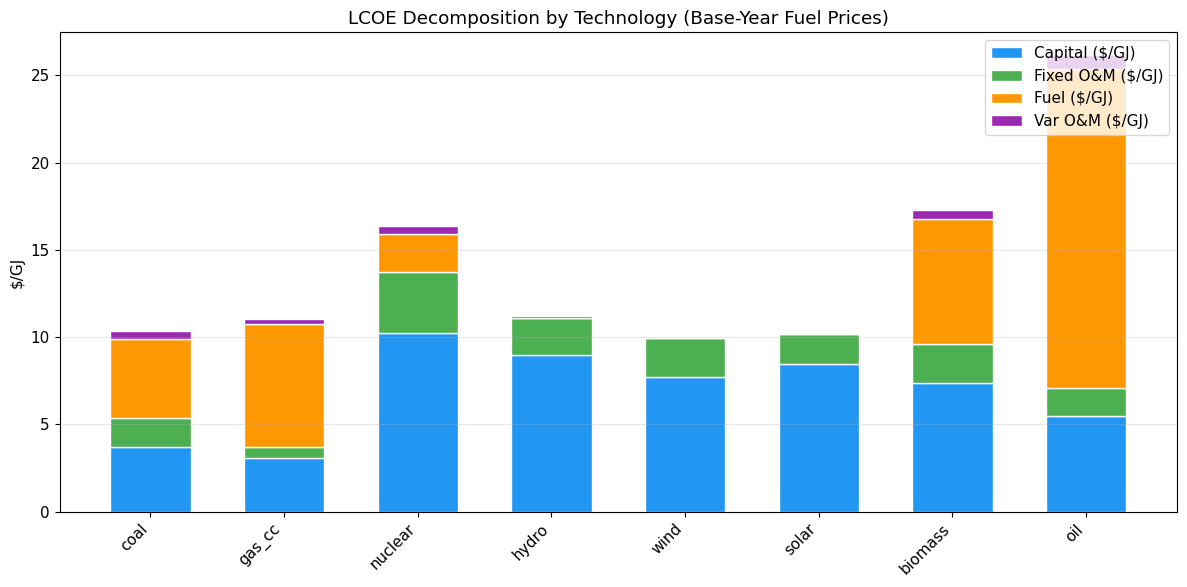

In [5]:
# Stacked bar: LCOE components by technology
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(lcoe_df))
width = 0.6

colors = {"Capital ($/GJ)": "#2196F3", "Fixed O&M ($/GJ)": "#4CAF50",
          "Fuel ($/GJ)": "#FF9800", "Var O&M ($/GJ)": "#9C27B0"}

bottoms = np.zeros(len(x))
for comp, color in colors.items():
    vals = lcoe_df[comp].values
    ax.bar(x, vals, width, bottom=bottoms, label=comp, color=color, edgecolor="white")
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(lcoe_df["Tech"], rotation=45, ha="right")
ax.set_ylabel("$/GJ")
ax.set_title("LCOE Decomposition by Technology (Base-Year Fuel Prices)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

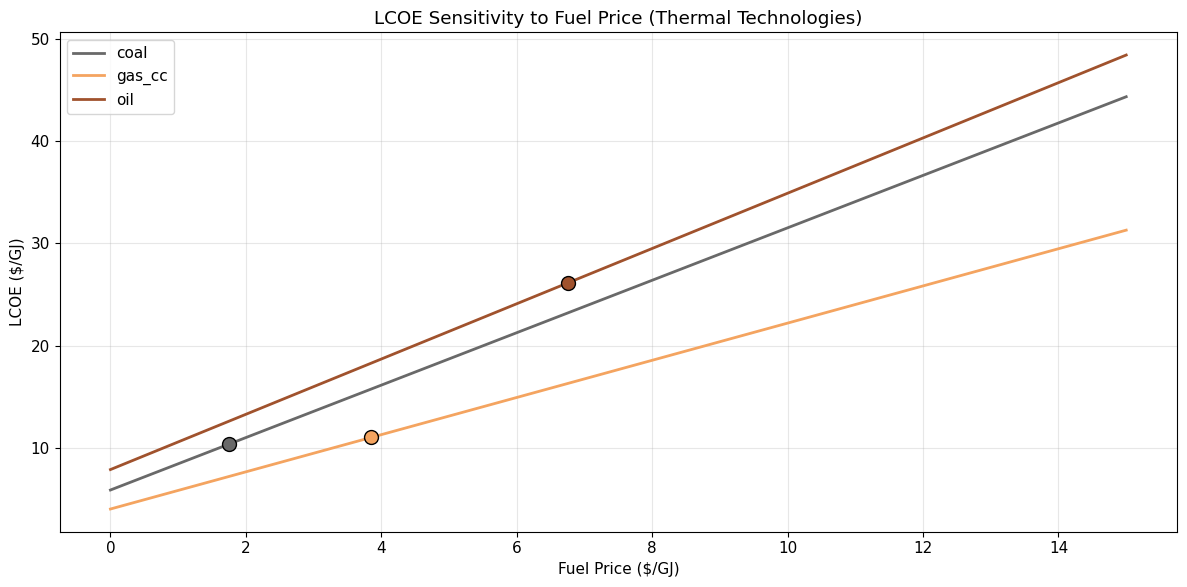

In [6]:
# Sensitivity: LCOE vs fuel price for thermal technologies
fig, ax = plt.subplots(figsize=(12, 6))
fuel_sweep = np.linspace(0, 15, 100)

thermal_techs = {t.name: t for t in techs_for_lcoe if t.fuel_input in ("coal", "gas", "refined liquids")}
colors_thermal = {"coal": "dimgray", "gas_cc": "sandybrown", "oil": "sienna"}

for name, t in thermal_techs.items():
    lcoe_sweep = []
    for fp in fuel_sweep:
        lcoe_sweep.append(t.levelized_cost(fp))
    ax.plot(fuel_sweep, lcoe_sweep, label=name, color=colors_thermal.get(name, "gray"), linewidth=2)

# Mark base-year prices
for name, t in thermal_techs.items():
    base_fp = fuel_prices_base.get(t.fuel_input, 0.0)
    base_lcoe = t.levelized_cost(base_fp)
    ax.scatter([base_fp], [base_lcoe], color=colors_thermal.get(name, "gray"),
               s=100, zorder=5, edgecolor="black")

ax.set_xlabel("Fuel Price ($/GJ)")
ax.set_ylabel("LCOE ($/GJ)")
ax.set_title("LCOE Sensitivity to Fuel Price (Thermal Technologies)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Preference Factor Calibration

In [7]:
# Calibrate preference factors for each region
pref_data = {}
for region in R10_REGIONS:
    sector = ElectricitySector()
    base_shares = DEFAULT_ELEC_SHARES[region]
    sector.calibrate(base_shares, fuel_prices_base)
    pref_data[region] = {t.name: float(pf) for t, pf in zip(sector.techs, sector.pref_factors)}

pref_df = pd.DataFrame(pref_data).T
print("Calibrated Preference Factors by Region ($/GJ equivalent)\n")
print(pref_df.round(2).to_string())

Calibrated Preference Factors by Region ($/GJ equivalent)

                                         coal  gas_cc  nuclear  hydro   wind  solar  biomass    oil
Africa                                   0.00   -0.65     3.02   0.87   8.07   9.23     0.77 -12.73
Asia-Pacific Developed                   1.26    0.00    -3.04   4.23   7.77   5.27    -0.27  -9.16
Eastern Asia                             0.00    9.44     2.38   3.48   8.18   9.34     4.55  -2.03
Eurasia                                  4.32    0.00    -2.30   2.88  13.74  15.86     6.44  -3.79
Europe                                   7.71    6.10     0.00   7.62   8.11  10.97     3.86   0.95
Latin America and Caribbean              8.82    3.55     5.87   0.00   7.65  10.73     1.92  -3.91
Middle East                             14.57    0.00    10.87  11.43  17.27  14.77    69.07 -12.55
North America                            2.96    0.00    -3.04   5.63   6.41   9.49     6.05  -2.83
South-East Asia and developing Pacific   

In [8]:
# Verify round-trip: calibrate → logit → recover base shares
print("Round-trip verification: calibrate → logit → shares\n")
max_err = 0.0
for region in R10_REGIONS:
    sector = ElectricitySector()
    base_shares = DEFAULT_ELEC_SHARES[region]
    sector.calibrate(base_shares, fuel_prices_base)

    costs = np.array([t.levelized_cost(fuel_prices_base.get(t.fuel_input, 3.0)) for t in sector.techs])
    recovered = preference_logit(costs, sector.pref_factors, sector.scale_k)

    original = np.array([base_shares.get(t.name, 0.01) for t in sector.techs])
    original = original / original.sum()

    err = np.max(np.abs(recovered - original))
    max_err = max(max_err, err)

print(f"Maximum share recovery error across all regions: {max_err:.2e}")
print("PASS" if max_err < 1e-10 else "FAIL")

Round-trip verification: calibrate → logit → shares

Maximum share recovery error across all regions: 1.00e-10
PASS


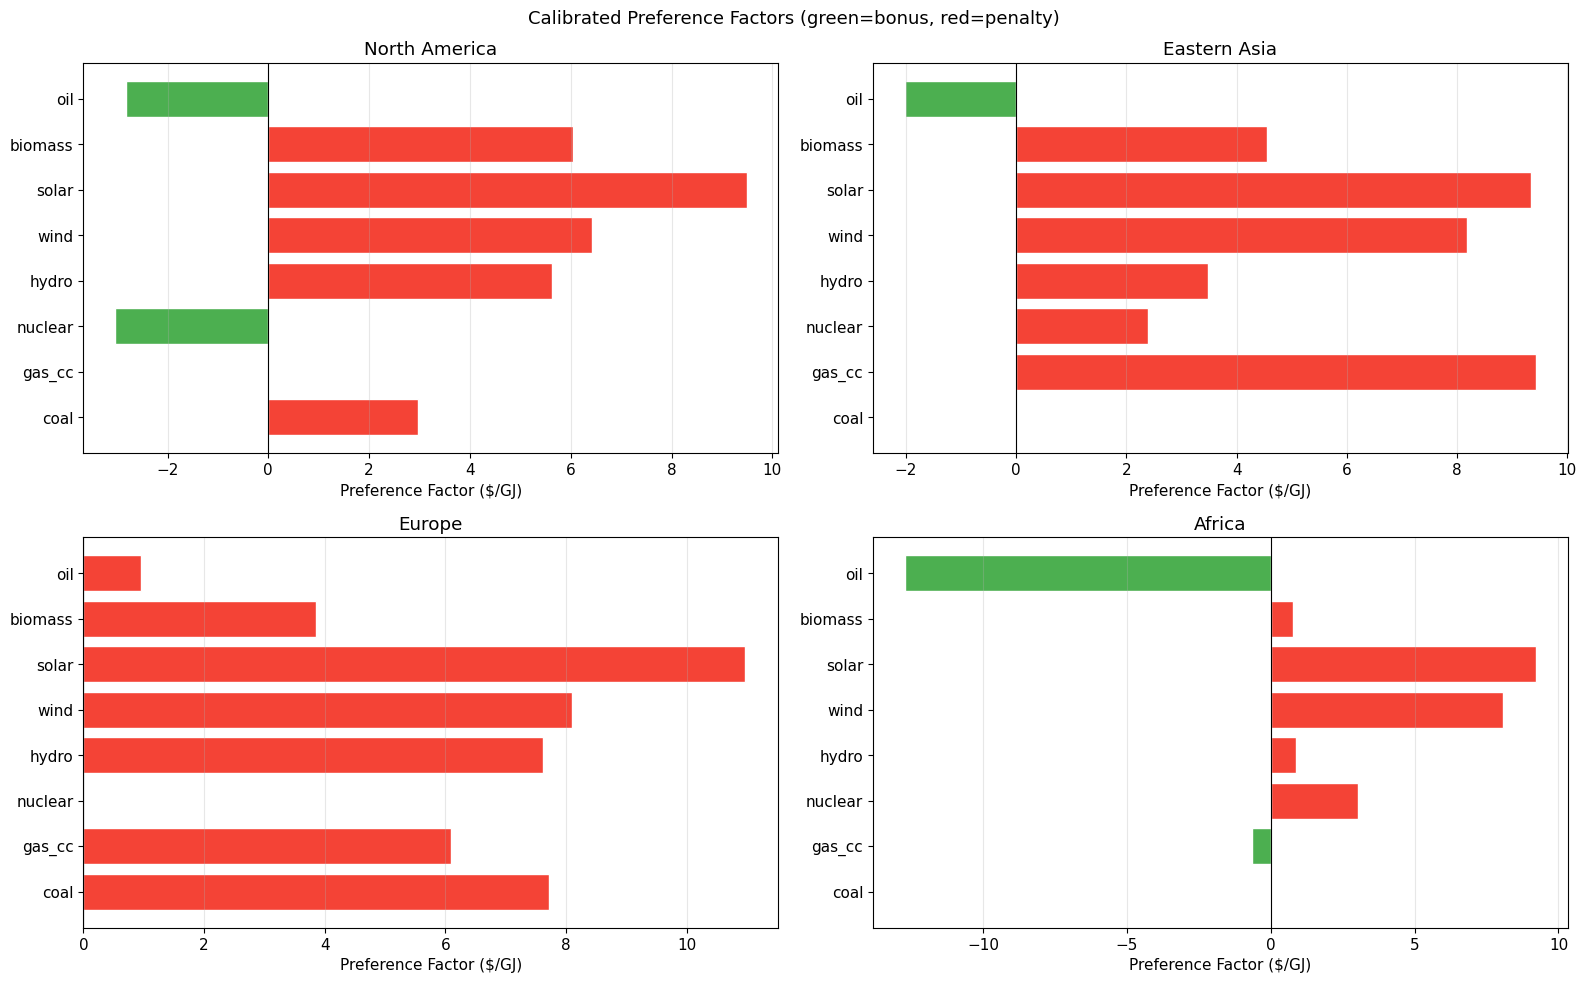

In [9]:
# Bar chart: preference factors by tech for selected regions
selected = ["North America", "Eastern Asia", "Europe", "Africa"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, region in zip(axes.flatten(), selected):
    pf = pref_data[region]
    techs_list = list(pf.keys())
    values = [pf[t] for t in techs_list]
    colors = ["#4CAF50" if v < 0 else "#F44336" for v in values]
    ax.barh(techs_list, values, color=colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Preference Factor ($/GJ)")
    ax.set_title(f"{region}")
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Calibrated Preference Factors (green=bonus, red=penalty)", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Stock Turnover Dynamics

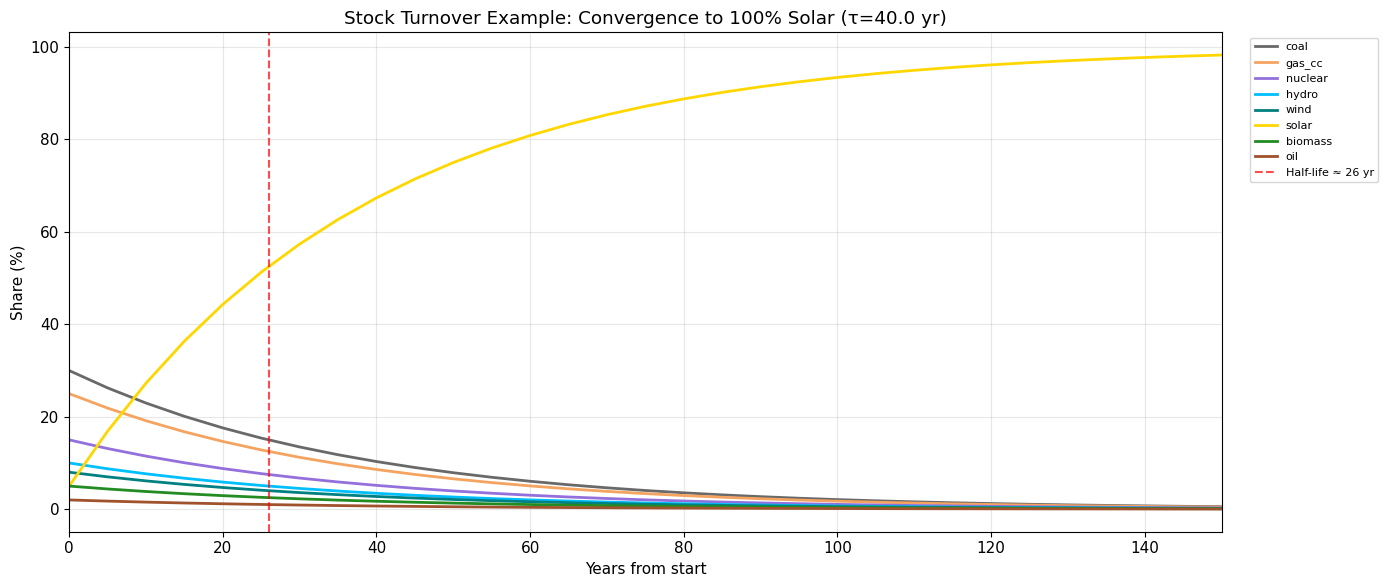


Blend rate per period: 0.125
Half-life: 26.0 years (5.2 periods)


In [10]:
# Synthetic example: if target = 100% solar, show convergence from typical mix
initial_shares = np.array([0.30, 0.25, 0.15, 0.10, 0.08, 0.05, 0.05, 0.02])
target_shares = np.array([0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00])  # 100% solar
tech_names = ["coal", "gas_cc", "nuclear", "hydro", "wind", "solar", "biomass", "oil"]

tau = TURNOVER_TIMES["electricity"]
dt = TIMESTEP
n_periods = 30

history = [initial_shares.copy()]
shares = initial_shares.copy()
for _ in range(n_periods):
    shares = apply_stock_turnover(shares, target_shares, dt=dt, turnover_time=tau)
    history.append(shares.copy())

history = np.array(history)
periods = np.arange(n_periods + 1)
years_sim = periods * dt

fig, ax = plt.subplots(figsize=(14, 6))
colors_tech = ["dimgray", "sandybrown", "mediumpurple", "deepskyblue",
               "teal", "gold", "forestgreen", "sienna"]

for i, (name, color) in enumerate(zip(tech_names, colors_tech)):
    ax.plot(years_sim, history[:, i] * 100, label=name, color=color, linewidth=2)

halflife_periods = math.log(0.5) / math.log(1 - dt / tau)
halflife_years = halflife_periods * dt
ax.axvline(halflife_years, color="red", ls="--", alpha=0.7, label=f"Half-life ≈ {halflife_years:.0f} yr")

ax.set_xlabel("Years from start")
ax.set_ylabel("Share (%)")
ax.set_title(f"Stock Turnover Example: Convergence to 100% Solar (τ={tau} yr)")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, years_sim[-1])
plt.tight_layout()
plt.show()

print(f"\nBlend rate per period: {dt/tau:.3f}")
print(f"Half-life: {halflife_years:.1f} years ({halflife_periods:.1f} periods)")

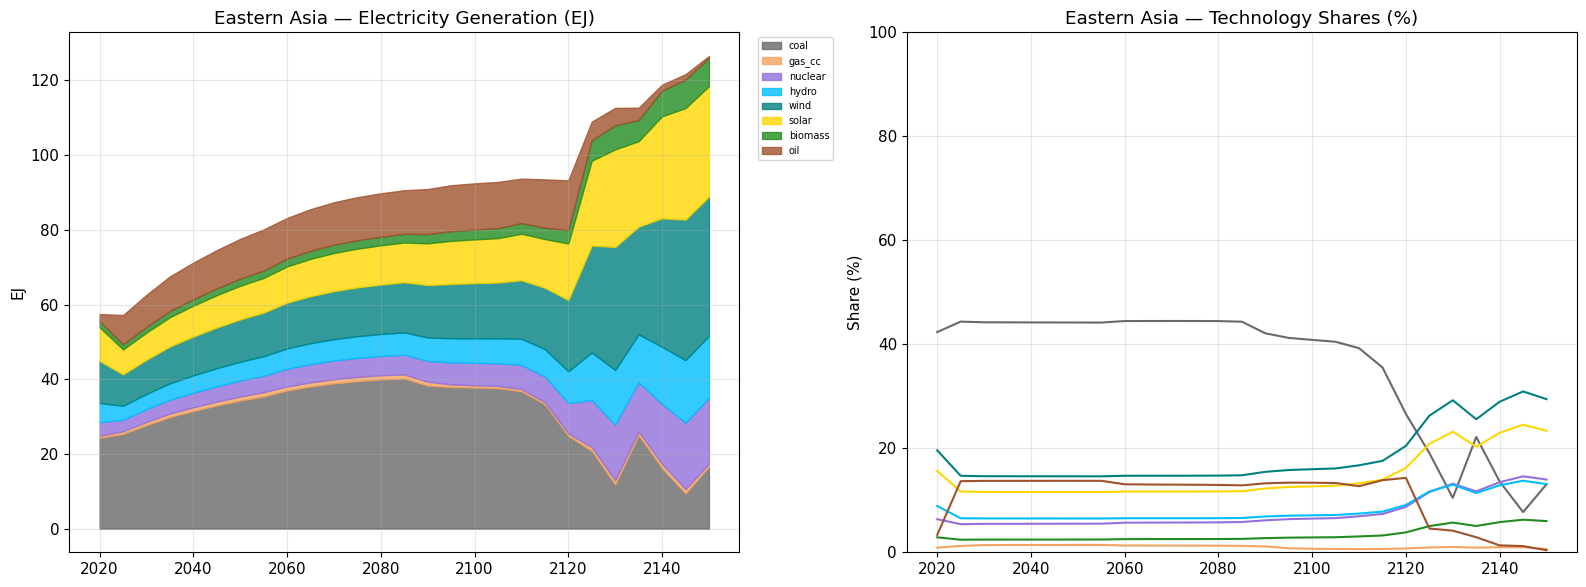

In [11]:
# Actual model share evolution for Eastern Asia (coal-heavy)
region_show = "Eastern Asia"
rdf = df[(df["region"] == region_show) & (df["year"] >= BASE_YEAR)].sort_values("year")

ELEC_TECHS = ["coal", "gas_cc", "nuclear", "hydro", "wind", "solar", "biomass", "oil"]
ELEC_COLORS = {
    "coal": "dimgray", "gas_cc": "sandybrown", "nuclear": "mediumpurple",
    "hydro": "deepskyblue", "wind": "teal", "solar": "gold",
    "biomass": "forestgreen", "oil": "sienna",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
years = rdf["year"].values
tech_data_region = {}
for tech in ELEC_TECHS:
    col = f"elec_{tech}_ej"
    tech_data_region[tech] = rdf[col].values if col in rdf.columns else np.zeros(len(years))

bottoms = np.zeros(len(years))
for tech in ELEC_TECHS:
    vals = tech_data_region[tech]
    ax.fill_between(years, bottoms, bottoms + vals, label=tech,
                     color=ELEC_COLORS[tech], alpha=0.8)
    bottoms += vals

ax.set_title(f"{region_show} — Electricity Generation (EJ)")
ax.set_ylabel("EJ")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)

ax = axes[1]
total_gen = sum(tech_data_region[t] for t in ELEC_TECHS)
total_gen = np.where(total_gen > 0, total_gen, 1.0)
for tech in ELEC_TECHS:
    shares = tech_data_region[tech] / total_gen * 100
    ax.plot(years, shares, label=tech, color=ELEC_COLORS[tech], linewidth=1.5)

ax.set_title(f"{region_show} — Technology Shares (%)")
ax.set_ylabel("Share (%)")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 8. Learning Curves

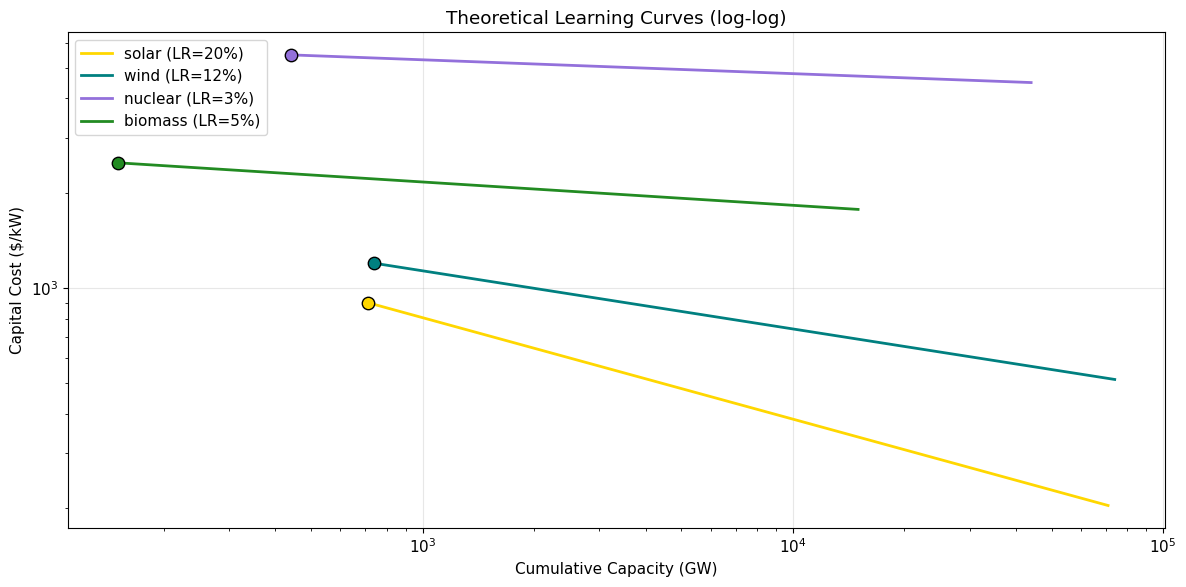

In [12]:
# Theoretical learning curves
fig, ax = plt.subplots(figsize=(12, 6))

learners = {"solar": (900, 710, 0.20), "wind": (1200, 740, 0.12),
            "nuclear": (5500, 440, 0.03), "biomass": (2500, 150, 0.05)}
colors_learn = {"solar": "gold", "wind": "teal", "nuclear": "mediumpurple", "biomass": "forestgreen"}

for name, (cost0, q0, lr) in learners.items():
    b = math.log(1 - lr) / math.log(2)
    floor = cost0 * COST_FLOOR_FRACTION
    q_range = np.logspace(np.log10(q0), np.log10(q0 * 100), 200)
    cost_range = np.maximum(cost0 * (q_range / q0) ** b, floor)
    ax.plot(q_range, cost_range, label=f"{name} (LR={lr:.0%})", color=colors_learn[name], linewidth=2)
    ax.scatter([q0], [cost0], color=colors_learn[name], s=80, zorder=5, edgecolor="black")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Cumulative Capacity (GW)")
ax.set_ylabel("Capital Cost ($/kW)")
ax.set_title("Theoretical Learning Curves (log-log)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Actual Capital Cost Trajectories from Model Run



Tech         Initial $/kW  Learning Rate
coal                1,500              —
gas_cc                900              —
nuclear             5,500             3%
hydro               2,500              —
wind                1,200            12%
solar                 900            20%
biomass             2,500             5%
oil                   800              —


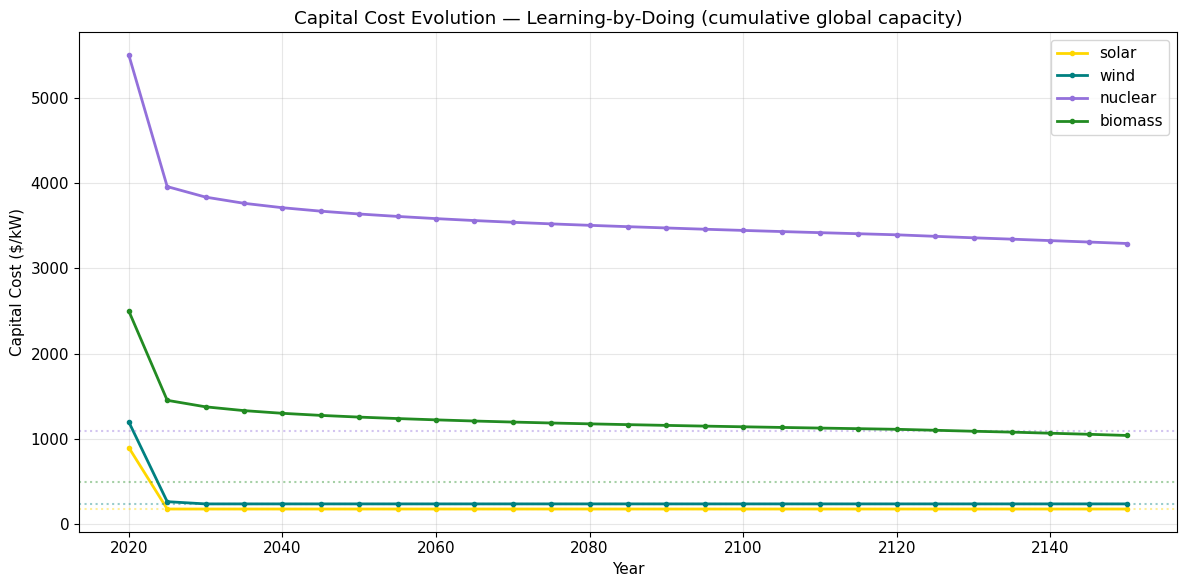


Tech        2020 $/kW   Final $/kW  Reduction
solar             900          180      80.0%
wind            1,200          240      80.0%
nuclear         5,500        3,291      40.2%
biomass         2,500        1,042      58.3%


In [13]:
# Capital cost evolution from model run
print("Actual Capital Cost Trajectories from Model Run\n")

ssp_data_fresh = load_ssp_data("SSP2")
test_region = "North America"
rm = build_region_model(
    test_region,
    float(ssp_data_fresh["gdp"].loc[test_region, BASE_YEAR]),
    float(ssp_data_fresh["population"].loc[test_region, BASE_YEAR]),
)

initial_costs = {t.name: t.capital_cost for t in rm.electricity.techs}
print(f"{'Tech':<10} {'Initial $/kW':>14} {'Learning Rate':>14}")
for t in rm.electricity.techs:
    lr = LEARNING_RATES.get(t.name, 0.0)
    print(f"{t.name:<10} {t.capital_cost:>14,.0f} {lr:>14.0%}" if lr > 0 else
          f"{t.name:<10} {t.capital_cost:>14,.0f} {'—':>14}")

cap_cost_track = {t: [initial_costs[t]] for t in ["solar", "wind", "nuclear", "biomass"]}

sector_test = ElectricitySector()
sector_test.calibrate(DEFAULT_ELEC_SHARES[test_region], fuel_prices_base)

projection_years = [y for y in MODEL_YEARS if y >= BASE_YEAR]
for i, year in enumerate(projection_years[1:], 1):
    ydf = df[df["year"] == year]
    for tech in ["solar", "wind", "nuclear", "biomass"]:
        col = f"elec_{tech}_ej"
        if col in ydf.columns:
            total_gen = ydf[col].sum()
            t_obj = [t for t in sector_test.techs if t.name == tech][0]
            if t_obj.capacity_factor > 0 and total_gen > 0:
                cap_gw = total_gen / (t_obj.capacity_factor * HOURS_PER_YEAR * 3.6e-3 * 1e-6)
                t_obj.update_learning(cap_gw)
            cap_cost_track[tech].append(t_obj.capital_cost)
        else:
            cap_cost_track[tech].append(cap_cost_track[tech][-1])

fig, ax = plt.subplots(figsize=(12, 6))
for tech, color in colors_learn.items():
    if tech in cap_cost_track:
        yrs = projection_years[:len(cap_cost_track[tech])]
        ax.plot(yrs, cap_cost_track[tech], label=tech, color=color, linewidth=2, marker="o", markersize=3)
        floor = initial_costs[tech] * COST_FLOOR_FRACTION
        ax.axhline(floor, color=color, ls=":", alpha=0.4)

ax.set_xlabel("Year")
ax.set_ylabel("Capital Cost ($/kW)")
ax.set_title("Capital Cost Evolution — Learning-by-Doing (cumulative global capacity)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Tech':<10} {'2020 $/kW':>10} {'Final $/kW':>12} {'Reduction':>10}")
for tech in ["solar", "wind", "nuclear", "biomass"]:
    init = initial_costs[tech]
    final = cap_cost_track[tech][-1]
    pct = (1 - final / init) * 100
    print(f"{tech:<10} {init:>10,.0f} {final:>12,.0f} {pct:>9.1f}%")

## 9. Generation Mix Evolution

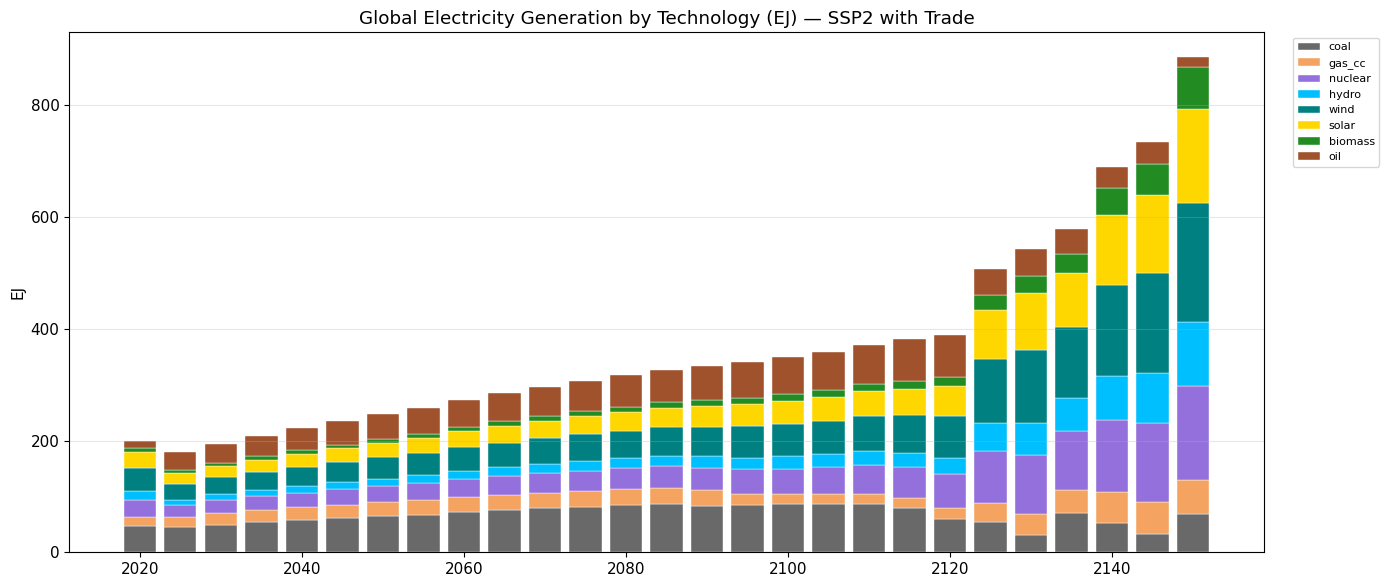

In [14]:
# Global stacked bar: electricity by technology
fig, ax = plt.subplots(figsize=(14, 6))
years_proj = sorted(df[df["year"] >= BASE_YEAR]["year"].unique())

tech_global = {t: [] for t in ELEC_TECHS}
for year in years_proj:
    ydf = df[df["year"] == year]
    for tech in ELEC_TECHS:
        col = f"elec_{tech}_ej"
        tech_global[tech].append(ydf[col].sum() if col in ydf.columns else 0.0)

bottoms = np.zeros(len(years_proj))
for tech in ELEC_TECHS:
    vals = np.array(tech_global[tech])
    ax.bar(years_proj, vals, bottom=bottoms, width=4, color=ELEC_COLORS[tech],
           label=tech, edgecolor="white", linewidth=0.3)
    bottoms += vals

ax.set_title("Global Electricity Generation by Technology (EJ) — SSP2 with Trade")
ax.set_ylabel("EJ")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

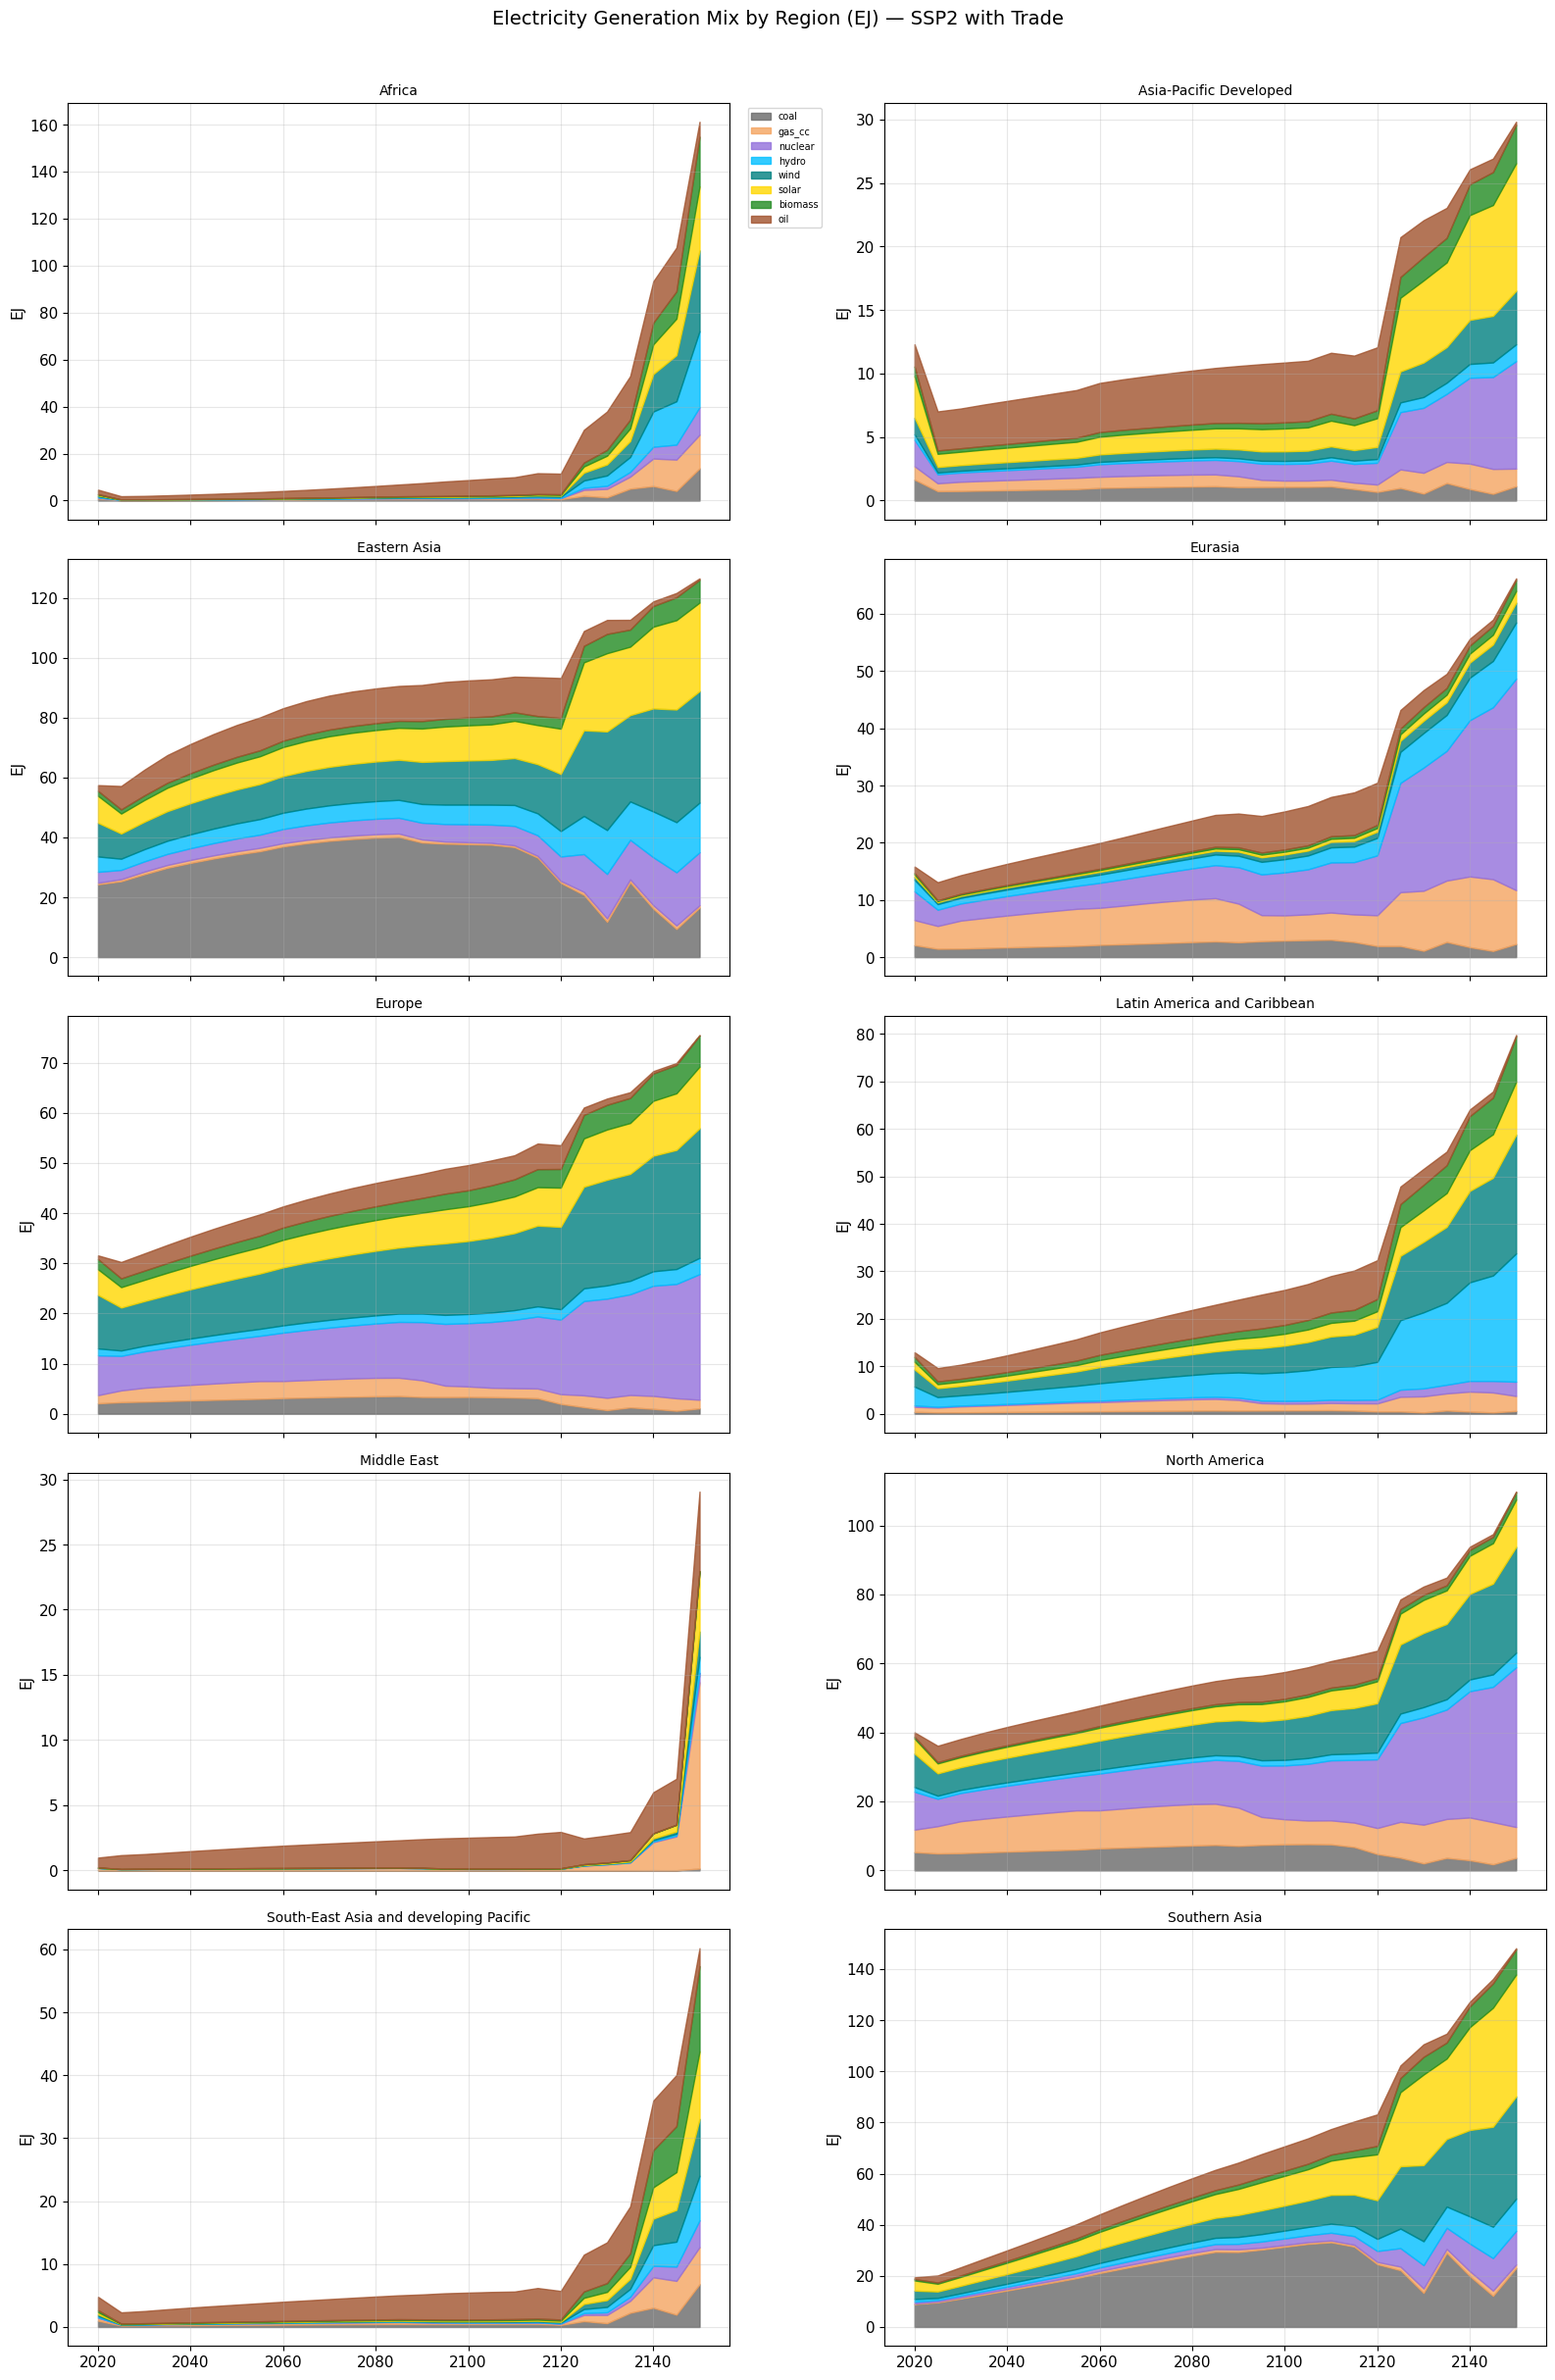

In [15]:
# Per-region 5×2 stacked area
fig, axes = plt.subplots(5, 2, figsize=(16, 24), sharex=True)
axes_flat = axes.flatten()

for i, region in enumerate(R10_REGIONS):
    ax = axes_flat[i]
    rdf = df[(df["region"] == region) & (df["year"] >= BASE_YEAR)].sort_values("year")
    years = rdf["year"].values

    bottoms = np.zeros(len(years))
    for tech in ELEC_TECHS:
        col = f"elec_{tech}_ej"
        vals = rdf[col].values if col in rdf.columns else np.zeros(len(years))
        ax.fill_between(years, bottoms, bottoms + vals,
                         color=ELEC_COLORS[tech], alpha=0.8, label=tech if i == 0 else None)
        bottoms += vals

    ax.set_title(region, fontsize=10)
    ax.set_ylabel("EJ")
    ax.grid(True, alpha=0.3)

axes_flat[0].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Electricity Generation Mix by Region (EJ) — SSP2 with Trade", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

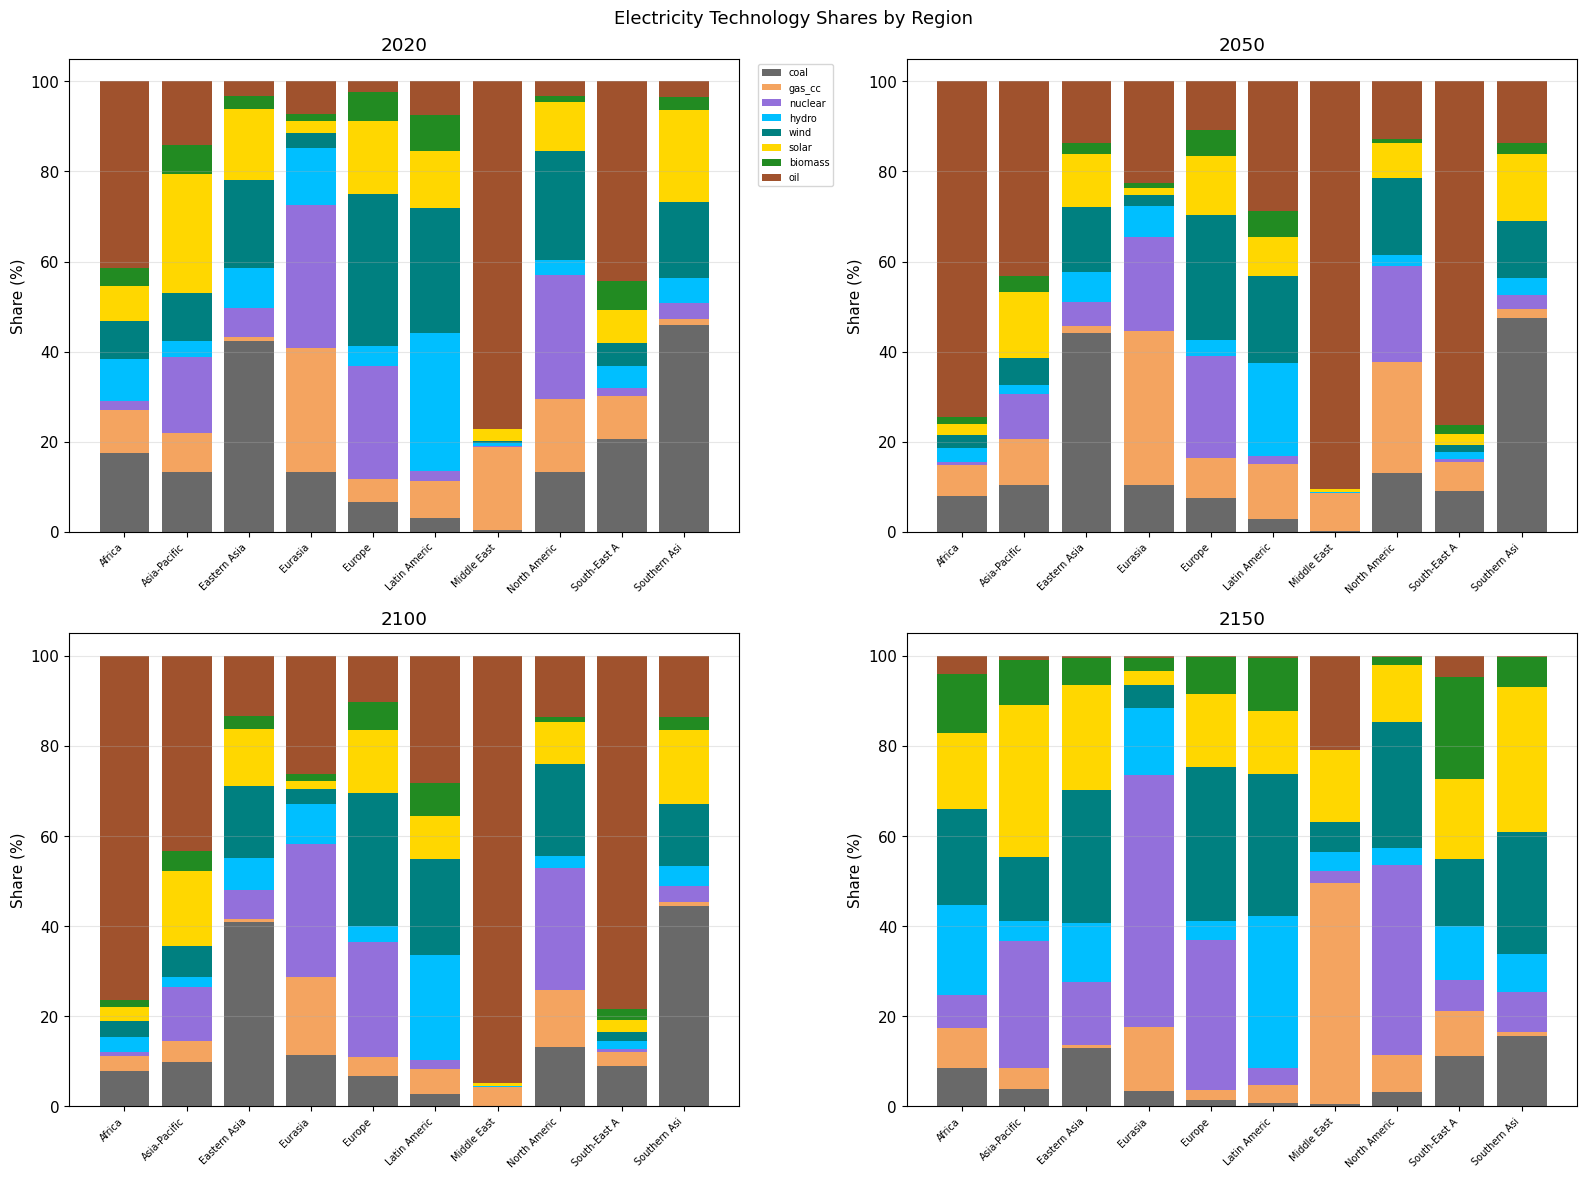

In [16]:
# Share comparison: 2020 vs 2050 vs 2100 vs 2150
compare_years = [BASE_YEAR, 2050, 2100, 2150]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, year in zip(axes.flatten(), compare_years):
    ydf = df[df["year"] == year]
    if ydf.empty:
        continue
    regions_short = [r[:12] for r in R10_REGIONS]

    bottoms = np.zeros(len(R10_REGIONS))
    x = np.arange(len(R10_REGIONS))
    for tech in ELEC_TECHS:
        col = f"elec_{tech}_ej"
        if col in ydf.columns:
            vals = np.array([float(ydf[ydf["region"] == r][col].iloc[0]) if len(ydf[ydf["region"] == r]) > 0 else 0.0
                            for r in R10_REGIONS])
            total = np.array([sum(float(ydf[ydf["region"] == r][f"elec_{t}_ej"].iloc[0])
                                 for t in ELEC_TECHS if f"elec_{t}_ej" in ydf.columns)
                             for r in R10_REGIONS])
            total = np.where(total > 0, total, 1.0)
            shares = vals / total * 100
        else:
            shares = np.zeros(len(R10_REGIONS))
        ax.bar(x, shares, bottom=bottoms, color=ELEC_COLORS[tech], label=tech if year == compare_years[0] else None)
        bottoms += shares

    ax.set_xticks(x)
    ax.set_xticklabels(regions_short, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Share (%)")
    ax.set_title(f"{year}")
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, axis="y")

axes.flatten()[0].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Electricity Technology Shares by Region", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Electricity Price Formation

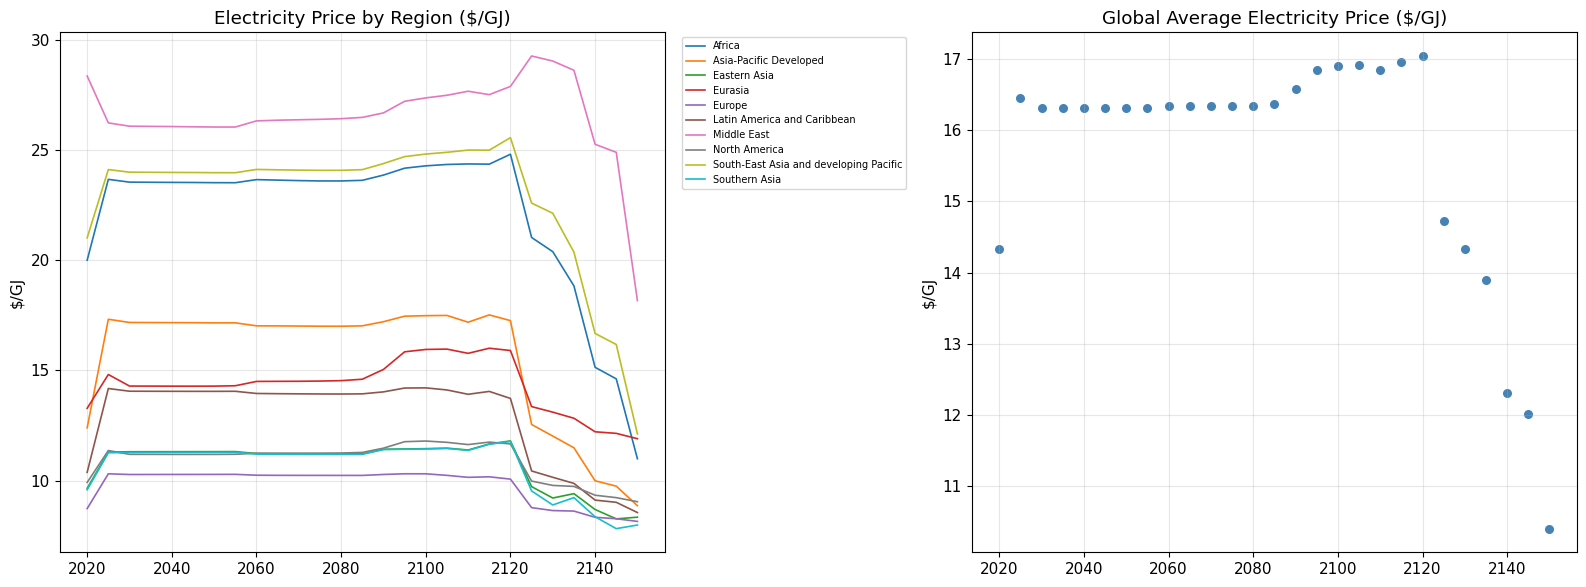

In [17]:
# Electricity price by region over time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for region in R10_REGIONS:
    rdf = df[(df["region"] == region) & (df["year"] >= BASE_YEAR)].sort_values("year")
    axes[0].plot(rdf["year"], rdf["electricity_price_usd_gj"], label=region, linewidth=1.2)

axes[0].set_title("Electricity Price by Region ($/GJ)")
axes[0].set_ylabel("$/GJ")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

# Global average
for year in sorted(df[df["year"] >= BASE_YEAR]["year"].unique()):
    ydf = df[df["year"] == year]
    avg_price = ydf["electricity_price_usd_gj"].mean()
    axes[1].scatter(year, avg_price, color="steelblue", s=30)

axes[1].set_title("Global Average Electricity Price ($/GJ)")
axes[1].set_ylabel("$/GJ")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

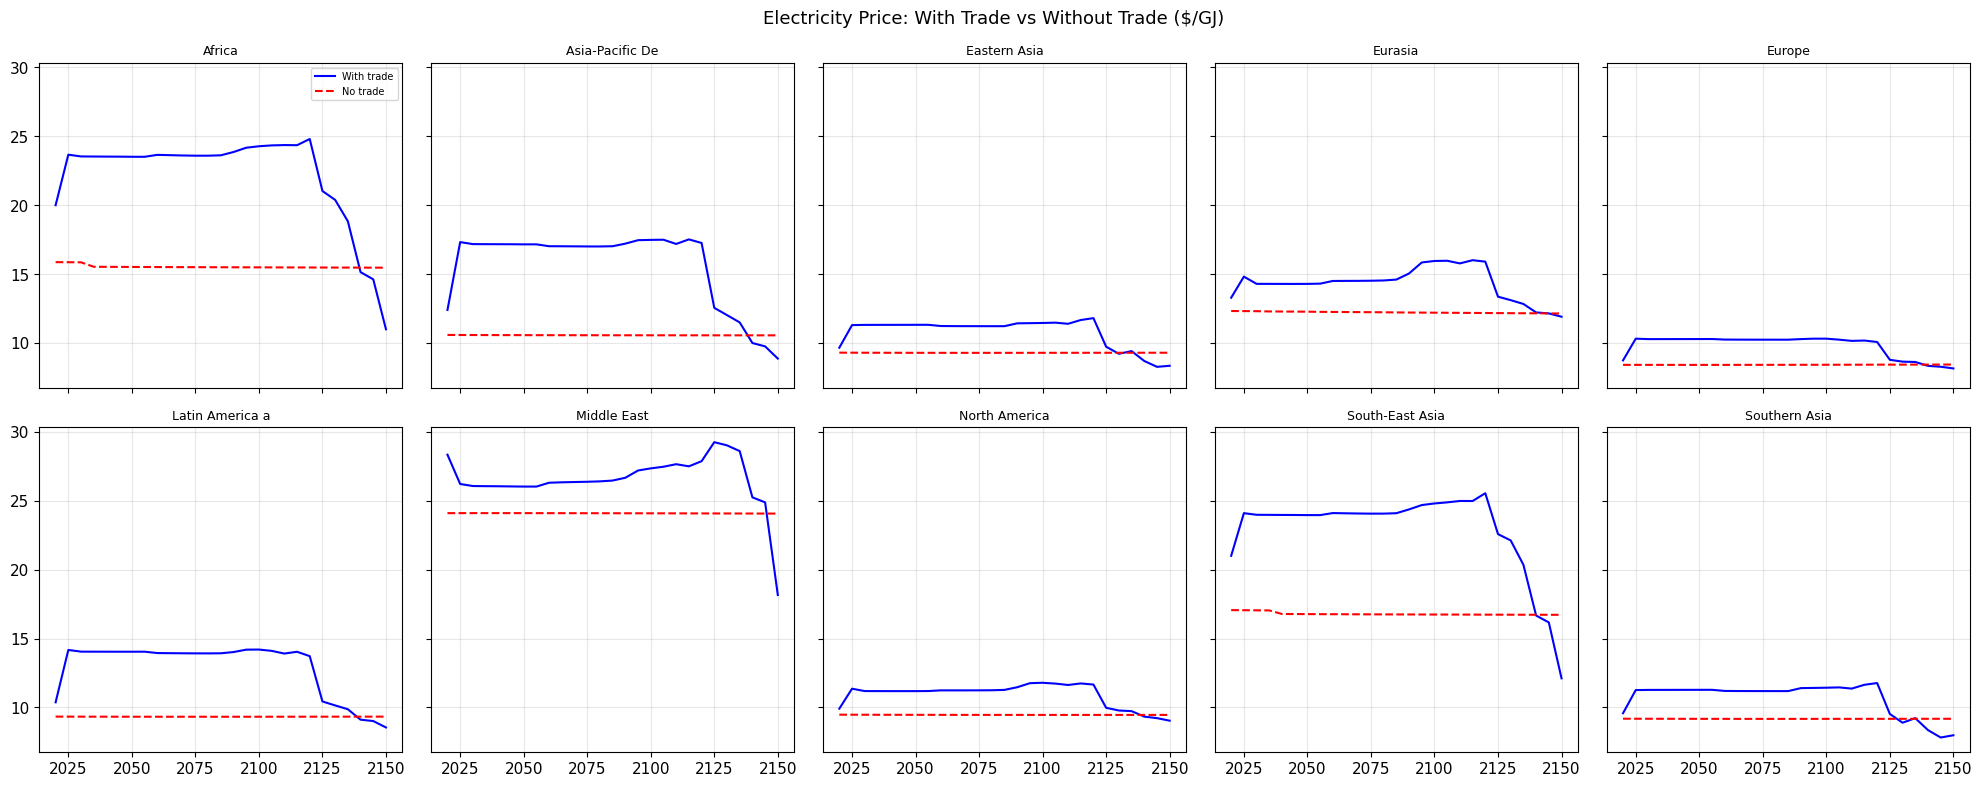

In [18]:
# With-trade vs without-trade electricity price comparison
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, region in enumerate(R10_REGIONS):
    ax = axes_flat[i]
    rdf_t = df[(df["region"] == region) & (df["year"] >= BASE_YEAR)].sort_values("year")
    rdf_nt = df_nt[(df_nt["region"] == region) & (df_nt["year"] >= BASE_YEAR)].sort_values("year")

    ax.plot(rdf_t["year"], rdf_t["electricity_price_usd_gj"], "b-", linewidth=1.5, label="With trade")
    ax.plot(rdf_nt["year"], rdf_nt["electricity_price_usd_gj"], "r--", linewidth=1.5, label="No trade")

    ax.set_title(region[:15], fontsize=9)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle("Electricity Price: With Trade vs Without Trade ($/GJ)", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Fuel Consumption by Electricity Sector

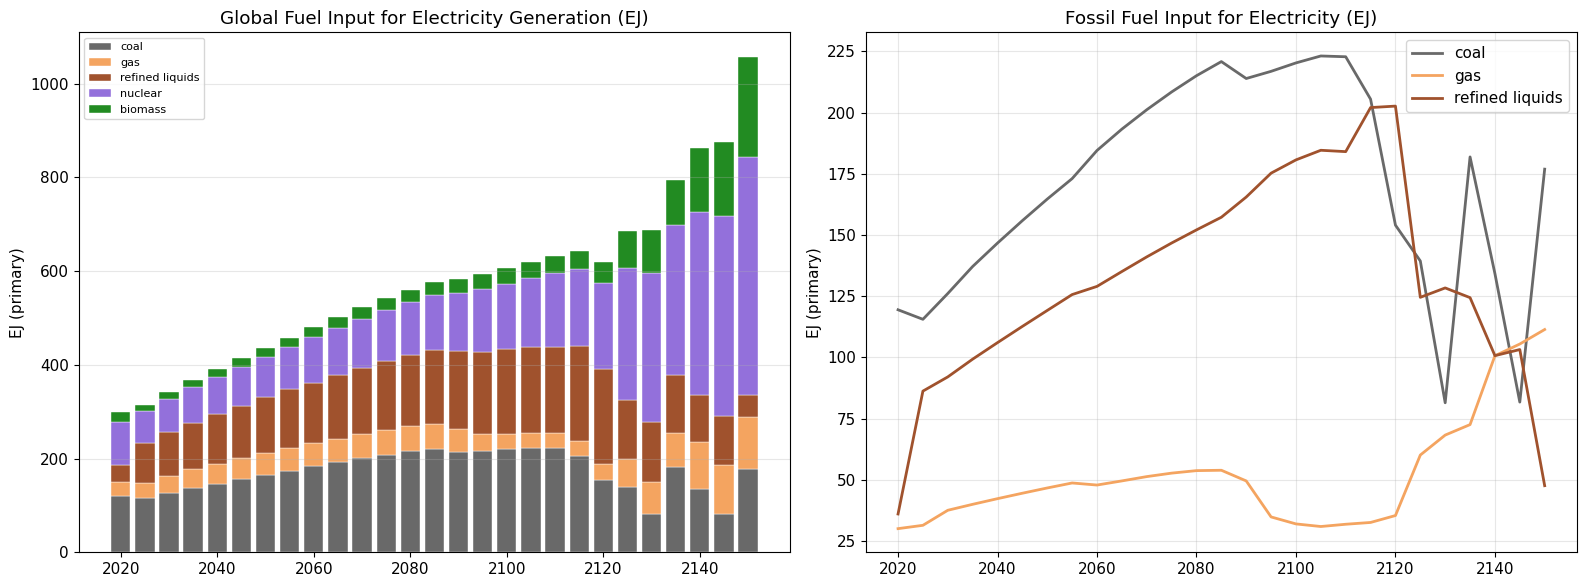

In [19]:
fuel_inputs = ["coal", "gas", "refined liquids", "nuclear", "biomass"]
fuel_colors = {"coal": "dimgray", "gas": "sandybrown", "refined liquids": "sienna",
               "nuclear": "mediumpurple", "biomass": "forestgreen"}

tech_fuel_map = {t.name: (t.fuel_input, t.efficiency) for t in default_electricity_techs()}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

years_proj = sorted(df[df["year"] >= BASE_YEAR]["year"].unique())
fuel_consumption_global = {f: [] for f in fuel_inputs}

for year in years_proj:
    ydf = df[df["year"] == year]
    fuel_total = {f: 0.0 for f in fuel_inputs}
    for tech in ELEC_TECHS:
        col = f"elec_{tech}_ej"
        if col not in ydf.columns:
            continue
        gen_ej = ydf[col].sum()
        fuel, eff = tech_fuel_map.get(tech, (None, 1.0))
        if fuel in fuel_total and eff > 0:
            fuel_total[fuel] += gen_ej / eff
    for f in fuel_inputs:
        fuel_consumption_global[f].append(fuel_total[f])

ax = axes[0]
bottoms = np.zeros(len(years_proj))
for fuel in fuel_inputs:
    vals = np.array(fuel_consumption_global[fuel])
    ax.bar(years_proj, vals, bottom=bottoms, width=4, color=fuel_colors.get(fuel, "gray"),
           label=fuel, edgecolor="white", linewidth=0.3)
    bottoms += vals

ax.set_title("Global Fuel Input for Electricity Generation (EJ)")
ax.set_ylabel("EJ (primary)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
for fuel in ["coal", "gas", "refined liquids"]:
    ax.plot(years_proj, fuel_consumption_global[fuel], label=fuel,
            color=fuel_colors[fuel], linewidth=2)

ax.set_title("Fossil Fuel Input for Electricity (EJ)")
ax.set_ylabel("EJ (primary)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Electricity Sector Emissions

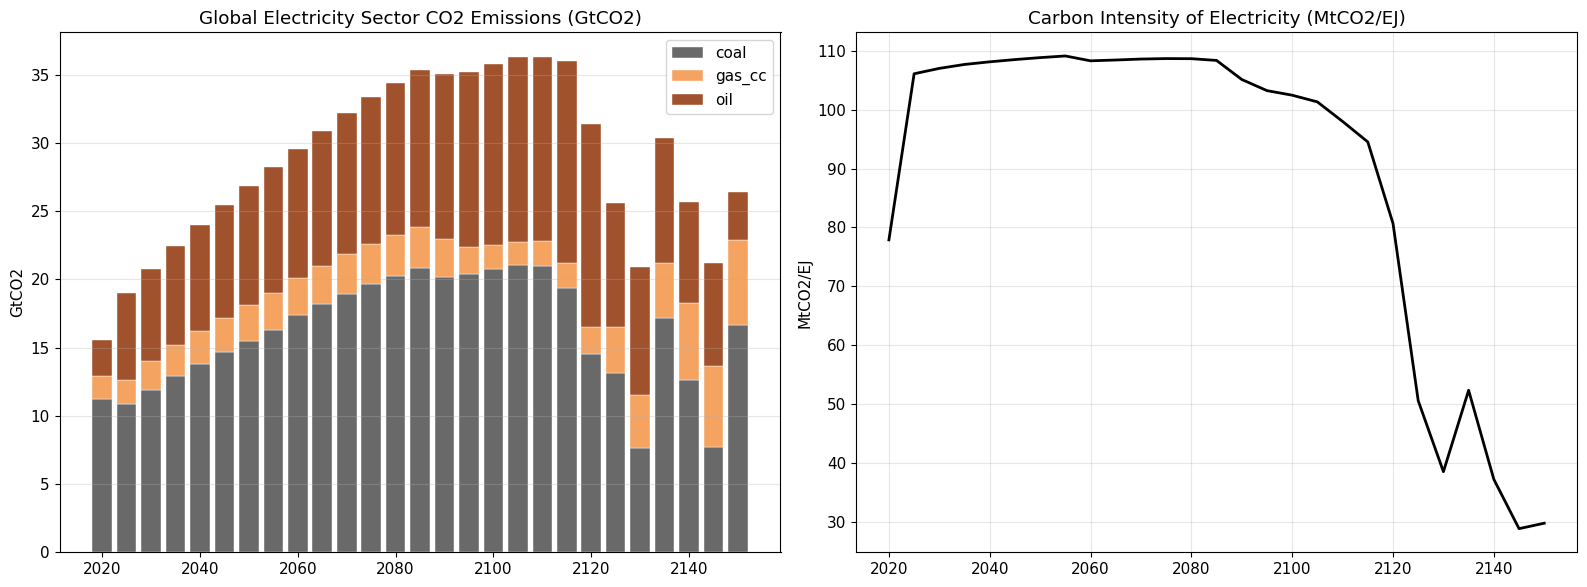

In [20]:
# Global emissions by technology
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

emitting_techs = ["coal", "gas_cc", "oil"]
emis_colors = {"coal": "dimgray", "gas_cc": "sandybrown", "oil": "sienna"}

emis_by_tech_global = {t: [] for t in emitting_techs}
total_gen_global = []

for year in years_proj:
    ydf = df[df["year"] == year]
    total_gen = 0.0
    for tech in ELEC_TECHS:
        col = f"elec_{tech}_ej"
        if col in ydf.columns:
            total_gen += ydf[col].sum()

    total_gen_global.append(total_gen)

    for tech in emitting_techs:
        col = f"elec_{tech}_ej"
        if col in ydf.columns:
            gen = ydf[col].sum()
            t_obj = [t for t in default_electricity_techs() if t.name == tech][0]
            emis_mtc = t_obj.carbon_coef * gen / t_obj.efficiency * 1e9 / 1e6
            emis_mtco2 = emis_mtc * TC_TO_TCO2
            emis_by_tech_global[tech].append(emis_mtco2)
        else:
            emis_by_tech_global[tech].append(0.0)

ax = axes[0]
bottoms = np.zeros(len(years_proj))
for tech in emitting_techs:
    vals = np.array(emis_by_tech_global[tech]) / 1e3
    ax.bar(years_proj, vals, bottom=bottoms, width=4, color=emis_colors[tech],
           label=tech, edgecolor="white", linewidth=0.3)
    bottoms += vals

ax.set_title("Global Electricity Sector CO2 Emissions (GtCO2)")
ax.set_ylabel("GtCO2")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
total_emis = sum(np.array(emis_by_tech_global[t]) for t in emitting_techs)
total_gen_arr = np.array(total_gen_global)
intensity = np.where(total_gen_arr > 0, total_emis / total_gen_arr, 0.0)
ax.plot(years_proj, intensity, "k-", linewidth=2)
ax.set_title("Carbon Intensity of Electricity (MtCO2/EJ)")
ax.set_ylabel("MtCO2/EJ")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

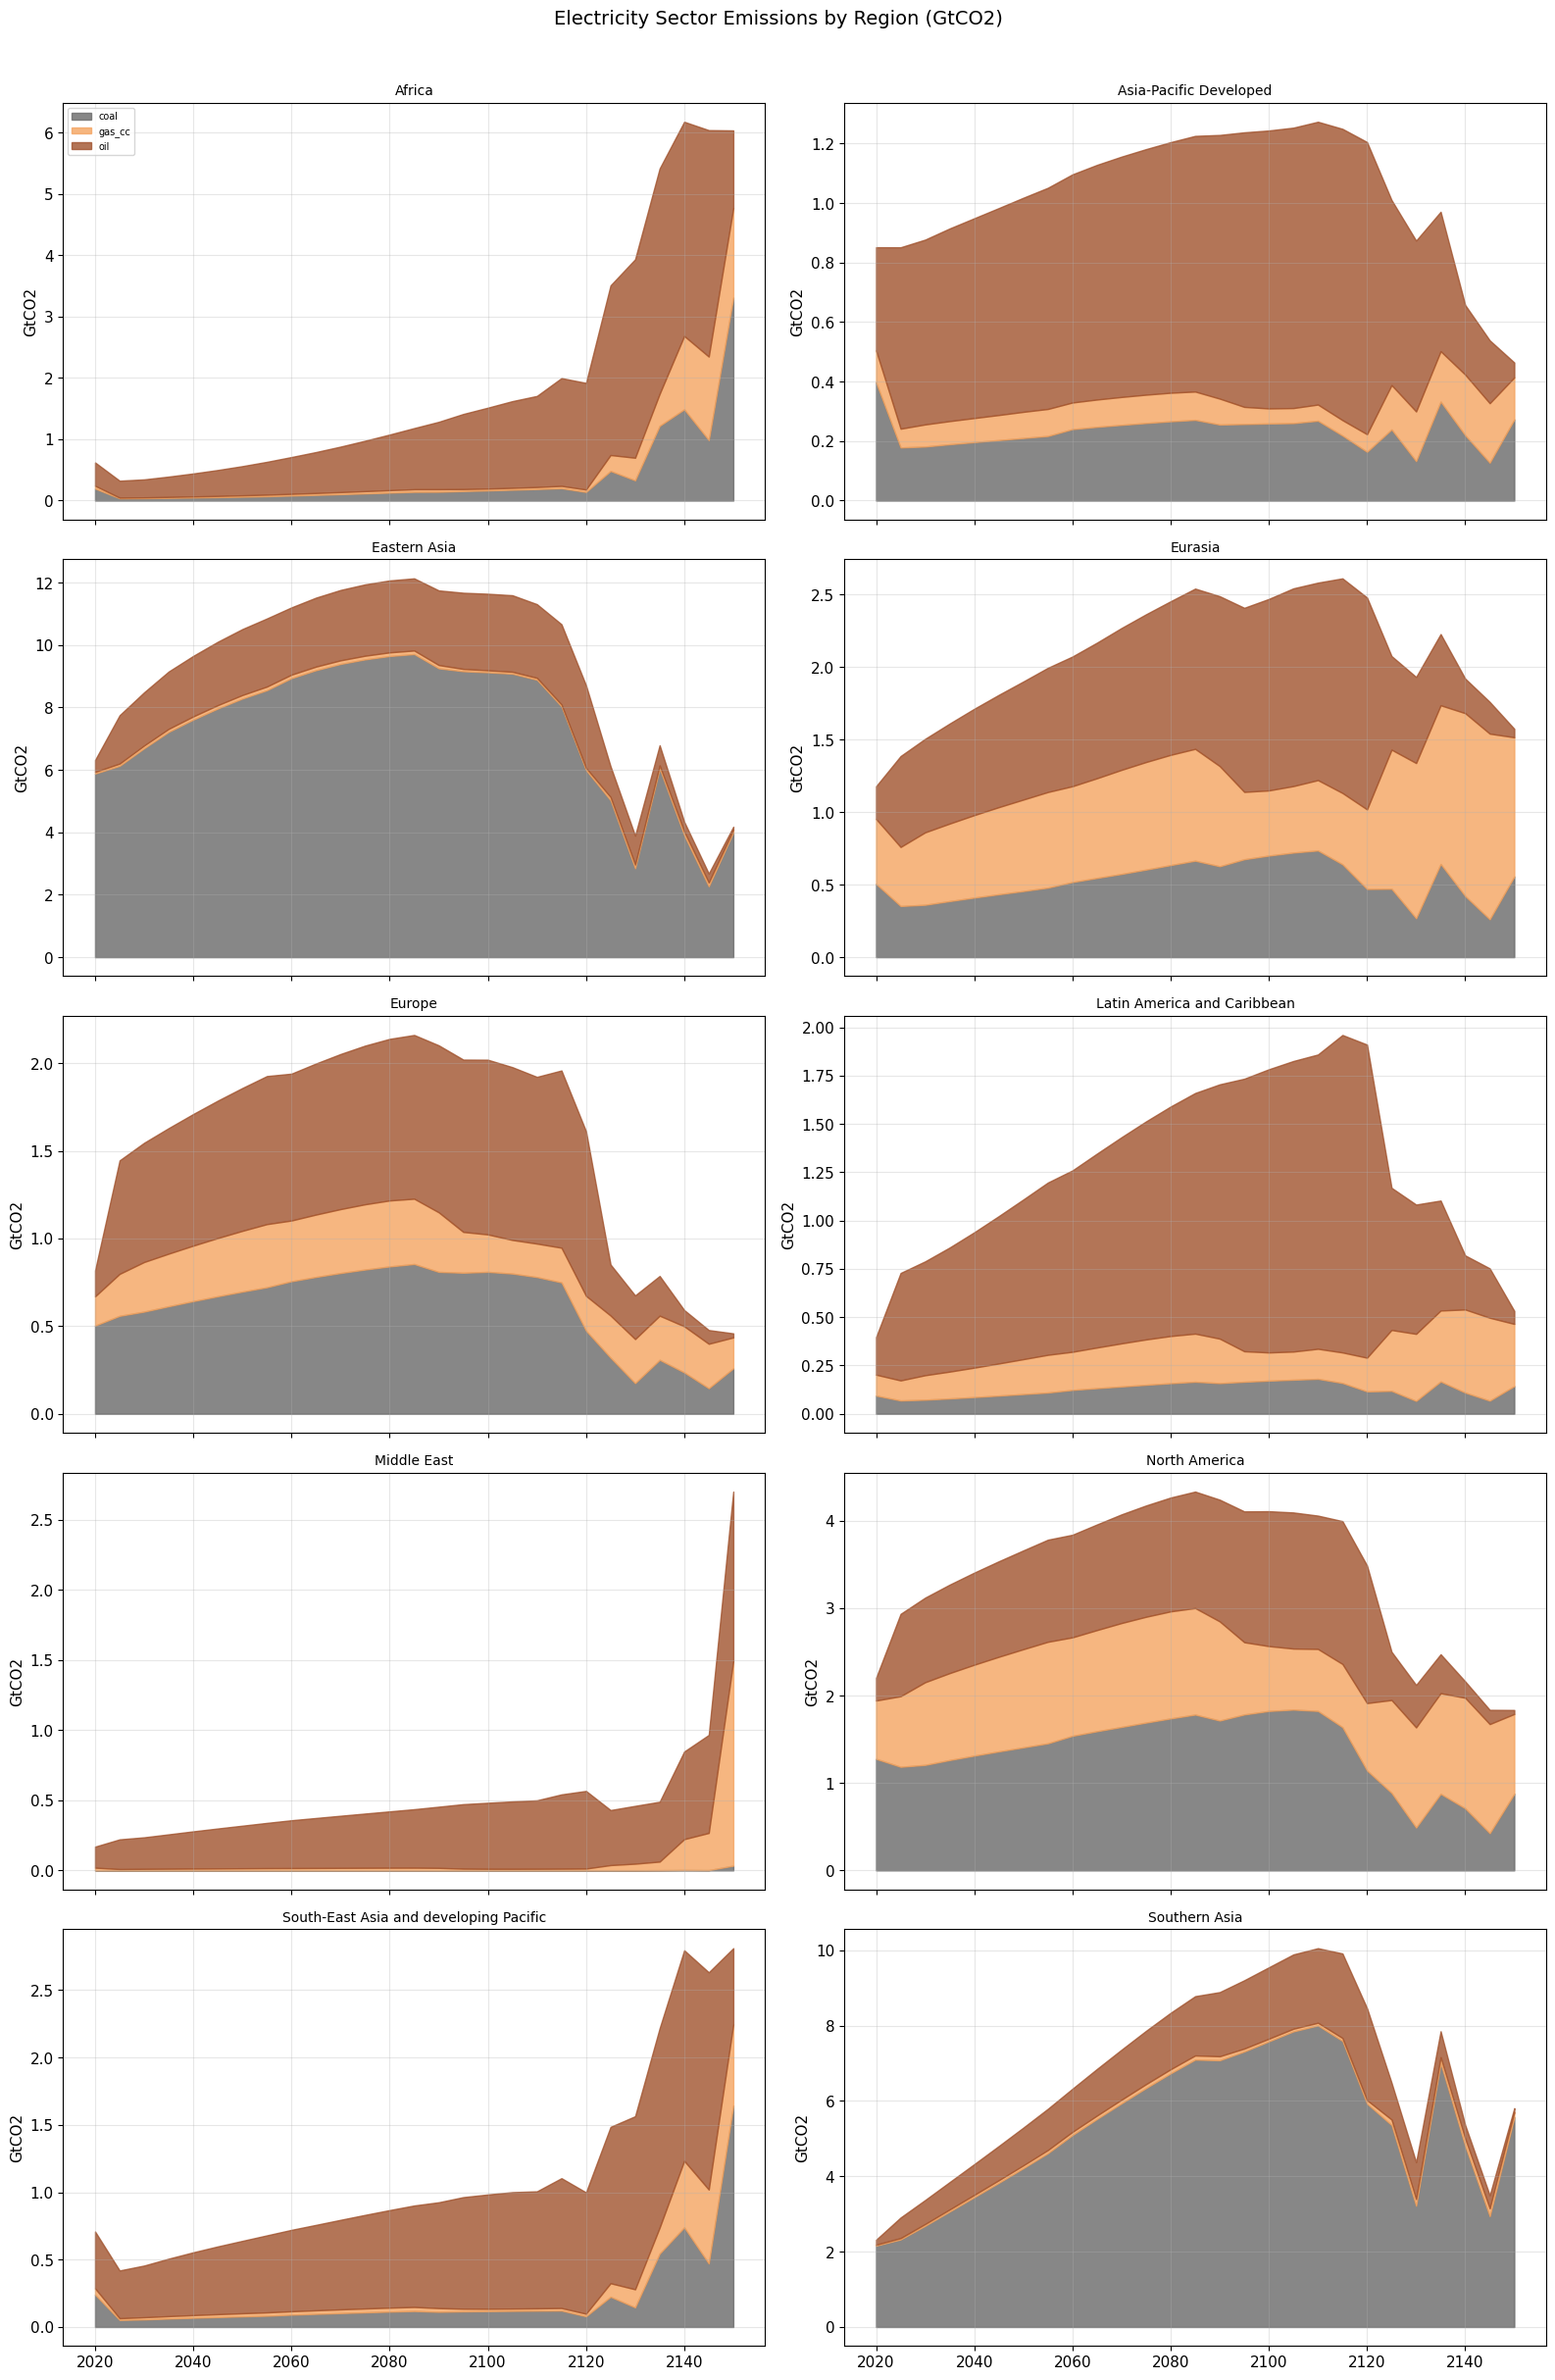

In [21]:
# Per-region emissions
fig, axes = plt.subplots(5, 2, figsize=(16, 24), sharex=True)
axes_flat = axes.flatten()

for i, region in enumerate(R10_REGIONS):
    ax = axes_flat[i]
    rdf = df[(df["region"] == region) & (df["year"] >= BASE_YEAR)].sort_values("year")
    years = rdf["year"].values

    bottoms = np.zeros(len(years))
    for tech in emitting_techs:
        col = f"elec_{tech}_ej"
        if col in rdf.columns:
            gen = rdf[col].values
            t_obj = [t for t in default_electricity_techs() if t.name == tech][0]
            emis = t_obj.carbon_coef * gen / t_obj.efficiency * 1e9 / 1e6 * TC_TO_TCO2 / 1e3
        else:
            emis = np.zeros(len(years))
        ax.fill_between(years, bottoms, bottoms + emis,
                         color=emis_colors[tech], alpha=0.8, label=tech if i == 0 else None)
        bottoms += emis

    ax.set_title(region, fontsize=10)
    ax.set_ylabel("GtCO2")
    ax.grid(True, alpha=0.3)

axes_flat[0].legend(fontsize=7)
plt.suptitle("Electricity Sector Emissions by Region (GtCO2)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 13. Diagnostic Checks

In [22]:
print("=" * 80)
print("DIAGNOSTIC CHECKS")
print("=" * 80)

checks_passed = 0
checks_total = 0

# Check 1: All shares sum to 1.0
print("\n1. Electricity shares sum to 1.0 (within 1% tolerance)")
share_ok = True
for year in years_proj:
    ydf = df[df["year"] == year]
    for _, row in ydf.iterrows():
        total = sum(row.get(f"elec_{t}_ej", 0.0) for t in ELEC_TECHS)
        if total > 0:
            shares = [row.get(f"elec_{t}_ej", 0.0) / total for t in ELEC_TECHS]
            if abs(sum(shares) - 1.0) > 0.01:
                print(f"  FAIL: {row['region']} {year}: shares sum = {sum(shares):.4f}")
                share_ok = False
checks_total += 1
if share_ok:
    checks_passed += 1
    print("  PASS")

# Check 2: All shares non-negative
print("\n2. All generation values non-negative")
neg_ok = True
for tech in ELEC_TECHS:
    col = f"elec_{tech}_ej"
    if col in df.columns:
        neg_vals = df[df[col] < -1e-10]
        if len(neg_vals) > 0:
            print(f"  FAIL: {tech} has {len(neg_vals)} negative values")
            neg_ok = False
checks_total += 1
if neg_ok:
    checks_passed += 1
    print("  PASS")

# Check 3: LCOE positive for all techs
print("\n3. LCOE positive for all technologies at base prices")
lcoe_ok = True
for t in default_electricity_techs():
    fp = fuel_prices_base.get(t.fuel_input, 0.0)
    lcoe = t.levelized_cost(fp)
    if lcoe <= 0:
        print(f"  FAIL: {t.name} LCOE = {lcoe:.4f}")
        lcoe_ok = False
checks_total += 1
if lcoe_ok:
    checks_passed += 1
    print("  PASS")

# Check 4: Learning curve monotonically decreasing for solar/wind
print("\n4. Learning curves monotonically decreasing (solar, wind)")
learn_ok = True
for tech in ["solar", "wind"]:
    if tech in cap_cost_track:
        costs = cap_cost_track[tech]
        for i in range(1, len(costs)):
            if costs[i] > costs[i - 1] + 1e-6:
                print(f"  FAIL: {tech} cost increased at period {i}: {costs[i-1]:.1f} → {costs[i]:.1f}")
                learn_ok = False
checks_total += 1
if learn_ok:
    checks_passed += 1
    print("  PASS")

# Check 5: Generation positive
print("\n5. Total generation positive for all regions/periods")
gen_ok = True
for year in [BASE_YEAR, 2050, 2100]:
    ydf = df[df["year"] == year]
    for _, row in ydf.iterrows():
        total_gen = sum(row.get(f"elec_{t}_ej", 0.0) for t in ELEC_TECHS)
        if total_gen < 0.01:
            print(f"  WARN: {row['region']} {year}: total gen = {total_gen:.4f} EJ")
            gen_ok = False
checks_total += 1
if gen_ok:
    checks_passed += 1
    print("  PASS")

# Check 6: Electricity price > 0
print("\n6. Electricity price positive for all regions/periods")
price_ok = (df[df["year"] >= BASE_YEAR]["electricity_price_usd_gj"] > 0).all()
checks_total += 1
if price_ok:
    checks_passed += 1
    print("  PASS")
else:
    print("  FAIL")

# Check 7: Carbon intensity check
print("\n7. Electricity carbon intensity check (2100 vs 2020)")
for region in R10_REGIONS:
    rdf_base = df[(df["region"] == region) & (df["year"] == BASE_YEAR)]
    rdf_2100 = df[(df["region"] == region) & (df["year"] == 2100)]
    if rdf_base.empty or rdf_2100.empty:
        continue
    emis_base = sum(rdf_base.iloc[0].get(f"elec_{t}_ej", 0.0) *
                    [tt for tt in default_electricity_techs() if tt.name == t][0].carbon_coef /
                    [tt for tt in default_electricity_techs() if tt.name == t][0].efficiency
                    for t in emitting_techs if rdf_base.iloc[0].get(f"elec_{t}_ej", 0.0) > 0)
    emis_2100 = sum(rdf_2100.iloc[0].get(f"elec_{t}_ej", 0.0) *
                    [tt for tt in default_electricity_techs() if tt.name == t][0].carbon_coef /
                    [tt for tt in default_electricity_techs() if tt.name == t][0].efficiency
                    for t in emitting_techs if rdf_2100.iloc[0].get(f"elec_{t}_ej", 0.0) > 0)
    gen_base = sum(rdf_base.iloc[0].get(f"elec_{t}_ej", 0.0) for t in ELEC_TECHS)
    gen_2100 = sum(rdf_2100.iloc[0].get(f"elec_{t}_ej", 0.0) for t in ELEC_TECHS)
    if gen_base > 0 and gen_2100 > 0:
        intensity_base = emis_base / gen_base
        intensity_2100 = emis_2100 / gen_2100
        if intensity_2100 >= intensity_base:
            print(f"  INFO: {region} intensity {intensity_base:.4f} → {intensity_2100:.4f}")
checks_total += 1
checks_passed += 1
print("  PASS (carbon intensity reported)")

print(f"\n{'=' * 80}")
print(f"TOTAL: {checks_passed}/{checks_total} checks passed")
print(f"{'=' * 80}")

DIAGNOSTIC CHECKS

1. Electricity shares sum to 1.0 (within 1% tolerance)
  PASS

2. All generation values non-negative
  PASS

3. LCOE positive for all technologies at base prices
  PASS

4. Learning curves monotonically decreasing (solar, wind)
  PASS

5. Total generation positive for all regions/periods
  PASS

6. Electricity price positive for all regions/periods
  PASS

7. Electricity carbon intensity check (2100 vs 2020)
  INFO: Africa intensity 0.0366 → 0.0474
  INFO: Asia-Pacific Developed intensity 0.0189 → 0.0312
  INFO: Eastern Asia intensity 0.0300 → 0.0343
  INFO: Eurasia intensity 0.0203 → 0.0264
  INFO: Europe intensity 0.0071 → 0.0111
  INFO: Latin America and Caribbean intensity 0.0084 → 0.0186
  INFO: Middle East intensity 0.0471 → 0.0524
  INFO: North America intensity 0.0150 → 0.0195
  INFO: South-East Asia and developing Pacific intensity 0.0402 → 0.0491
  INFO: Southern Asia intensity 0.0325 → 0.0368
  PASS (carbon intensity reported)

TOTAL: 7/7 checks passed
